# Recurrent Neural Nets

## 1. Answers

RNNs are used to process sequential data, like NLP - translation, word preditctions, text classification, they are widely used to process videos, stock prices, etc.

One-to-many: image descryption, weather prediction   
Many-to-many: text refactoring, video descryption   
Many-to-one: text mood classification, vider classification   

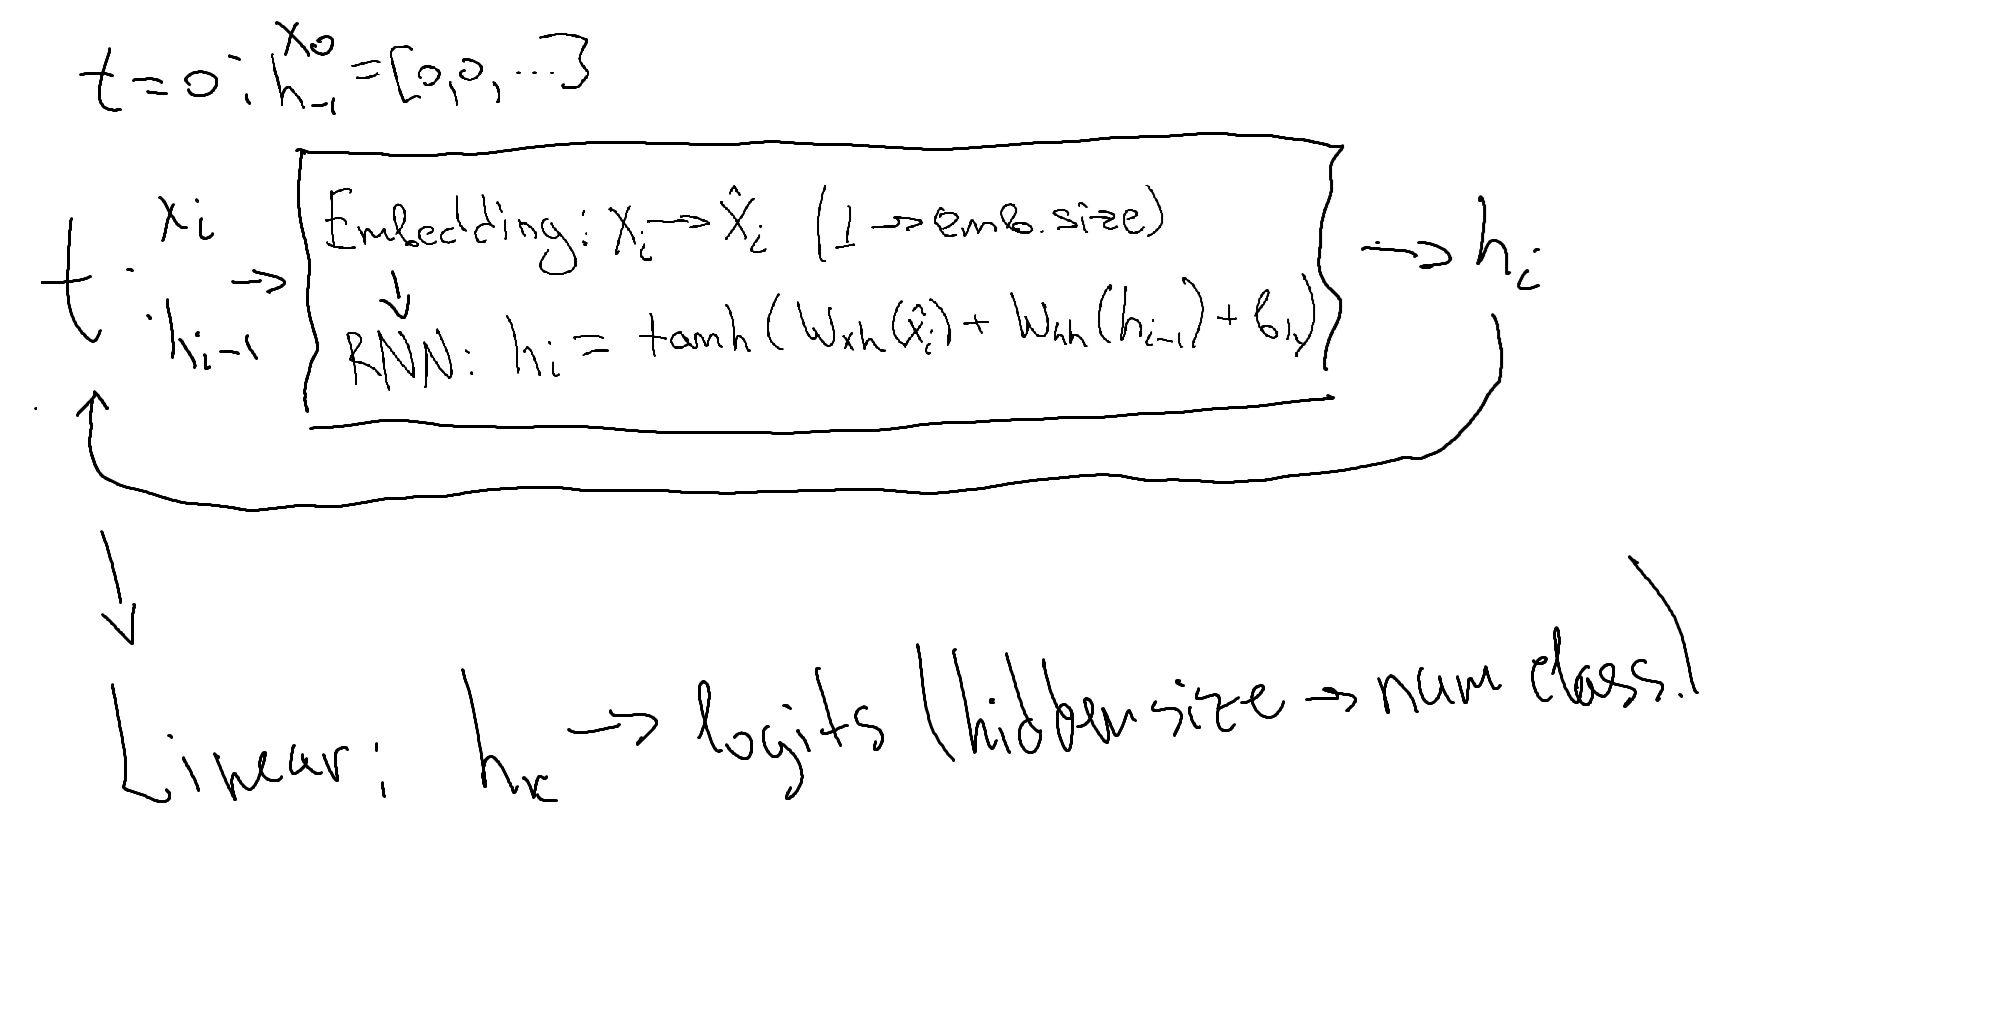

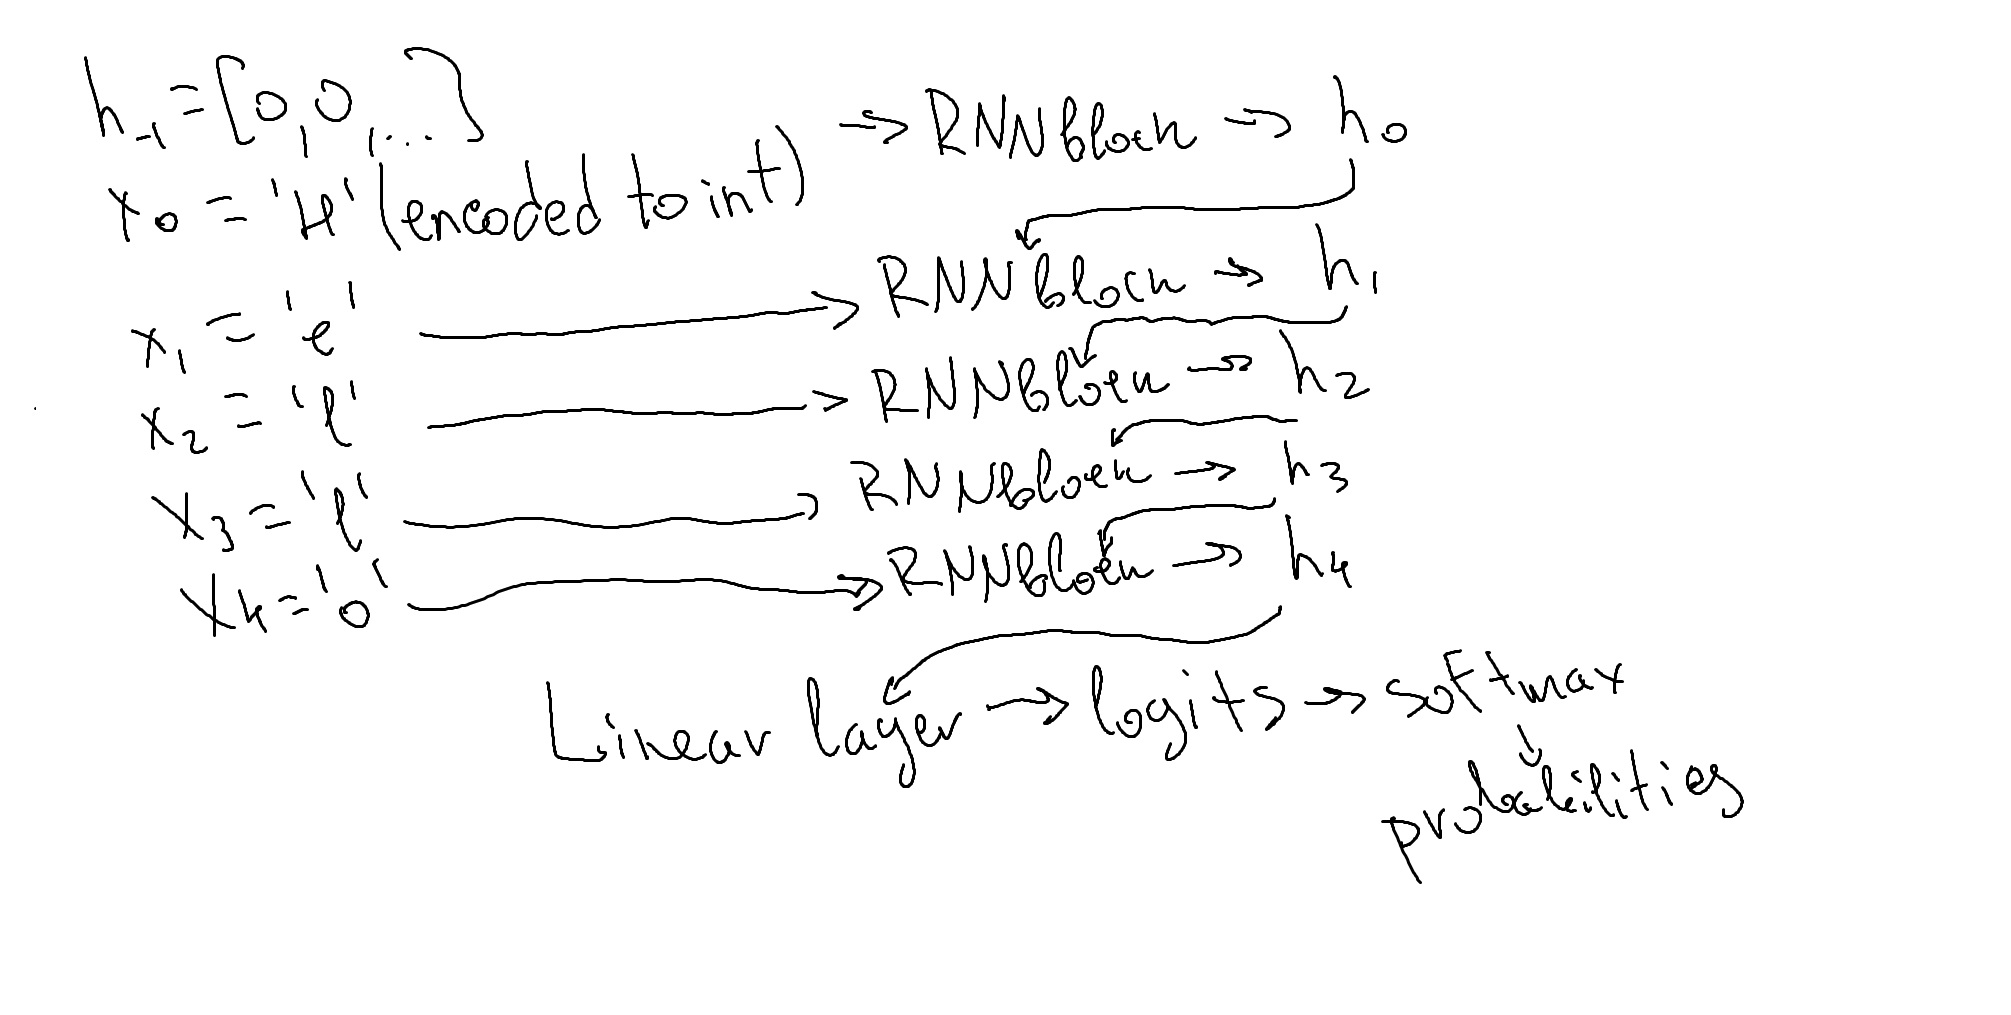

Compared to RNN, LSTM has 3 gates: input, forget, output. Which help to control what to update and what to delete. GRU on the other hand has 2 gates: reset and update, which produce results very similar to the LSTM, but require less computational capacity

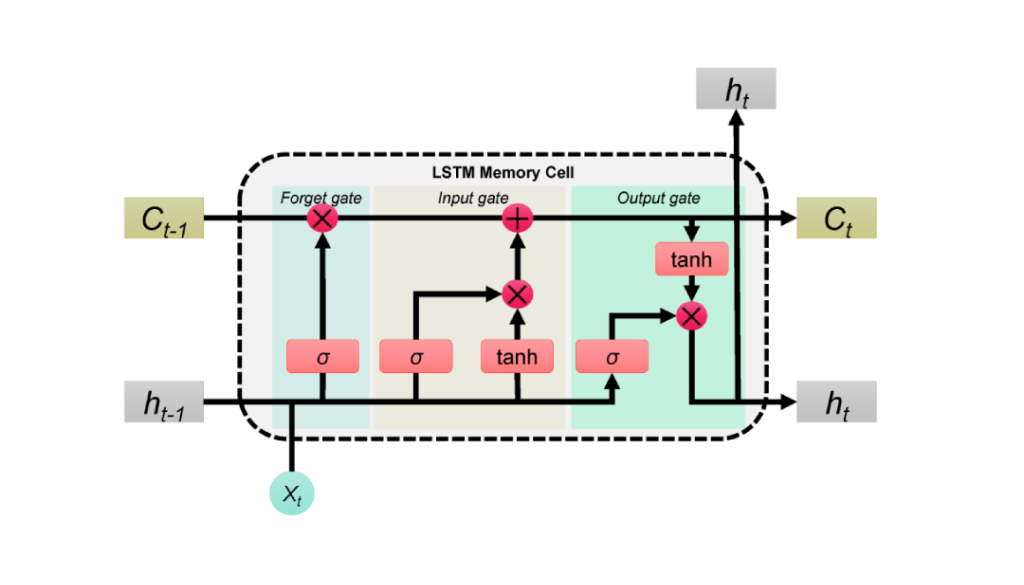

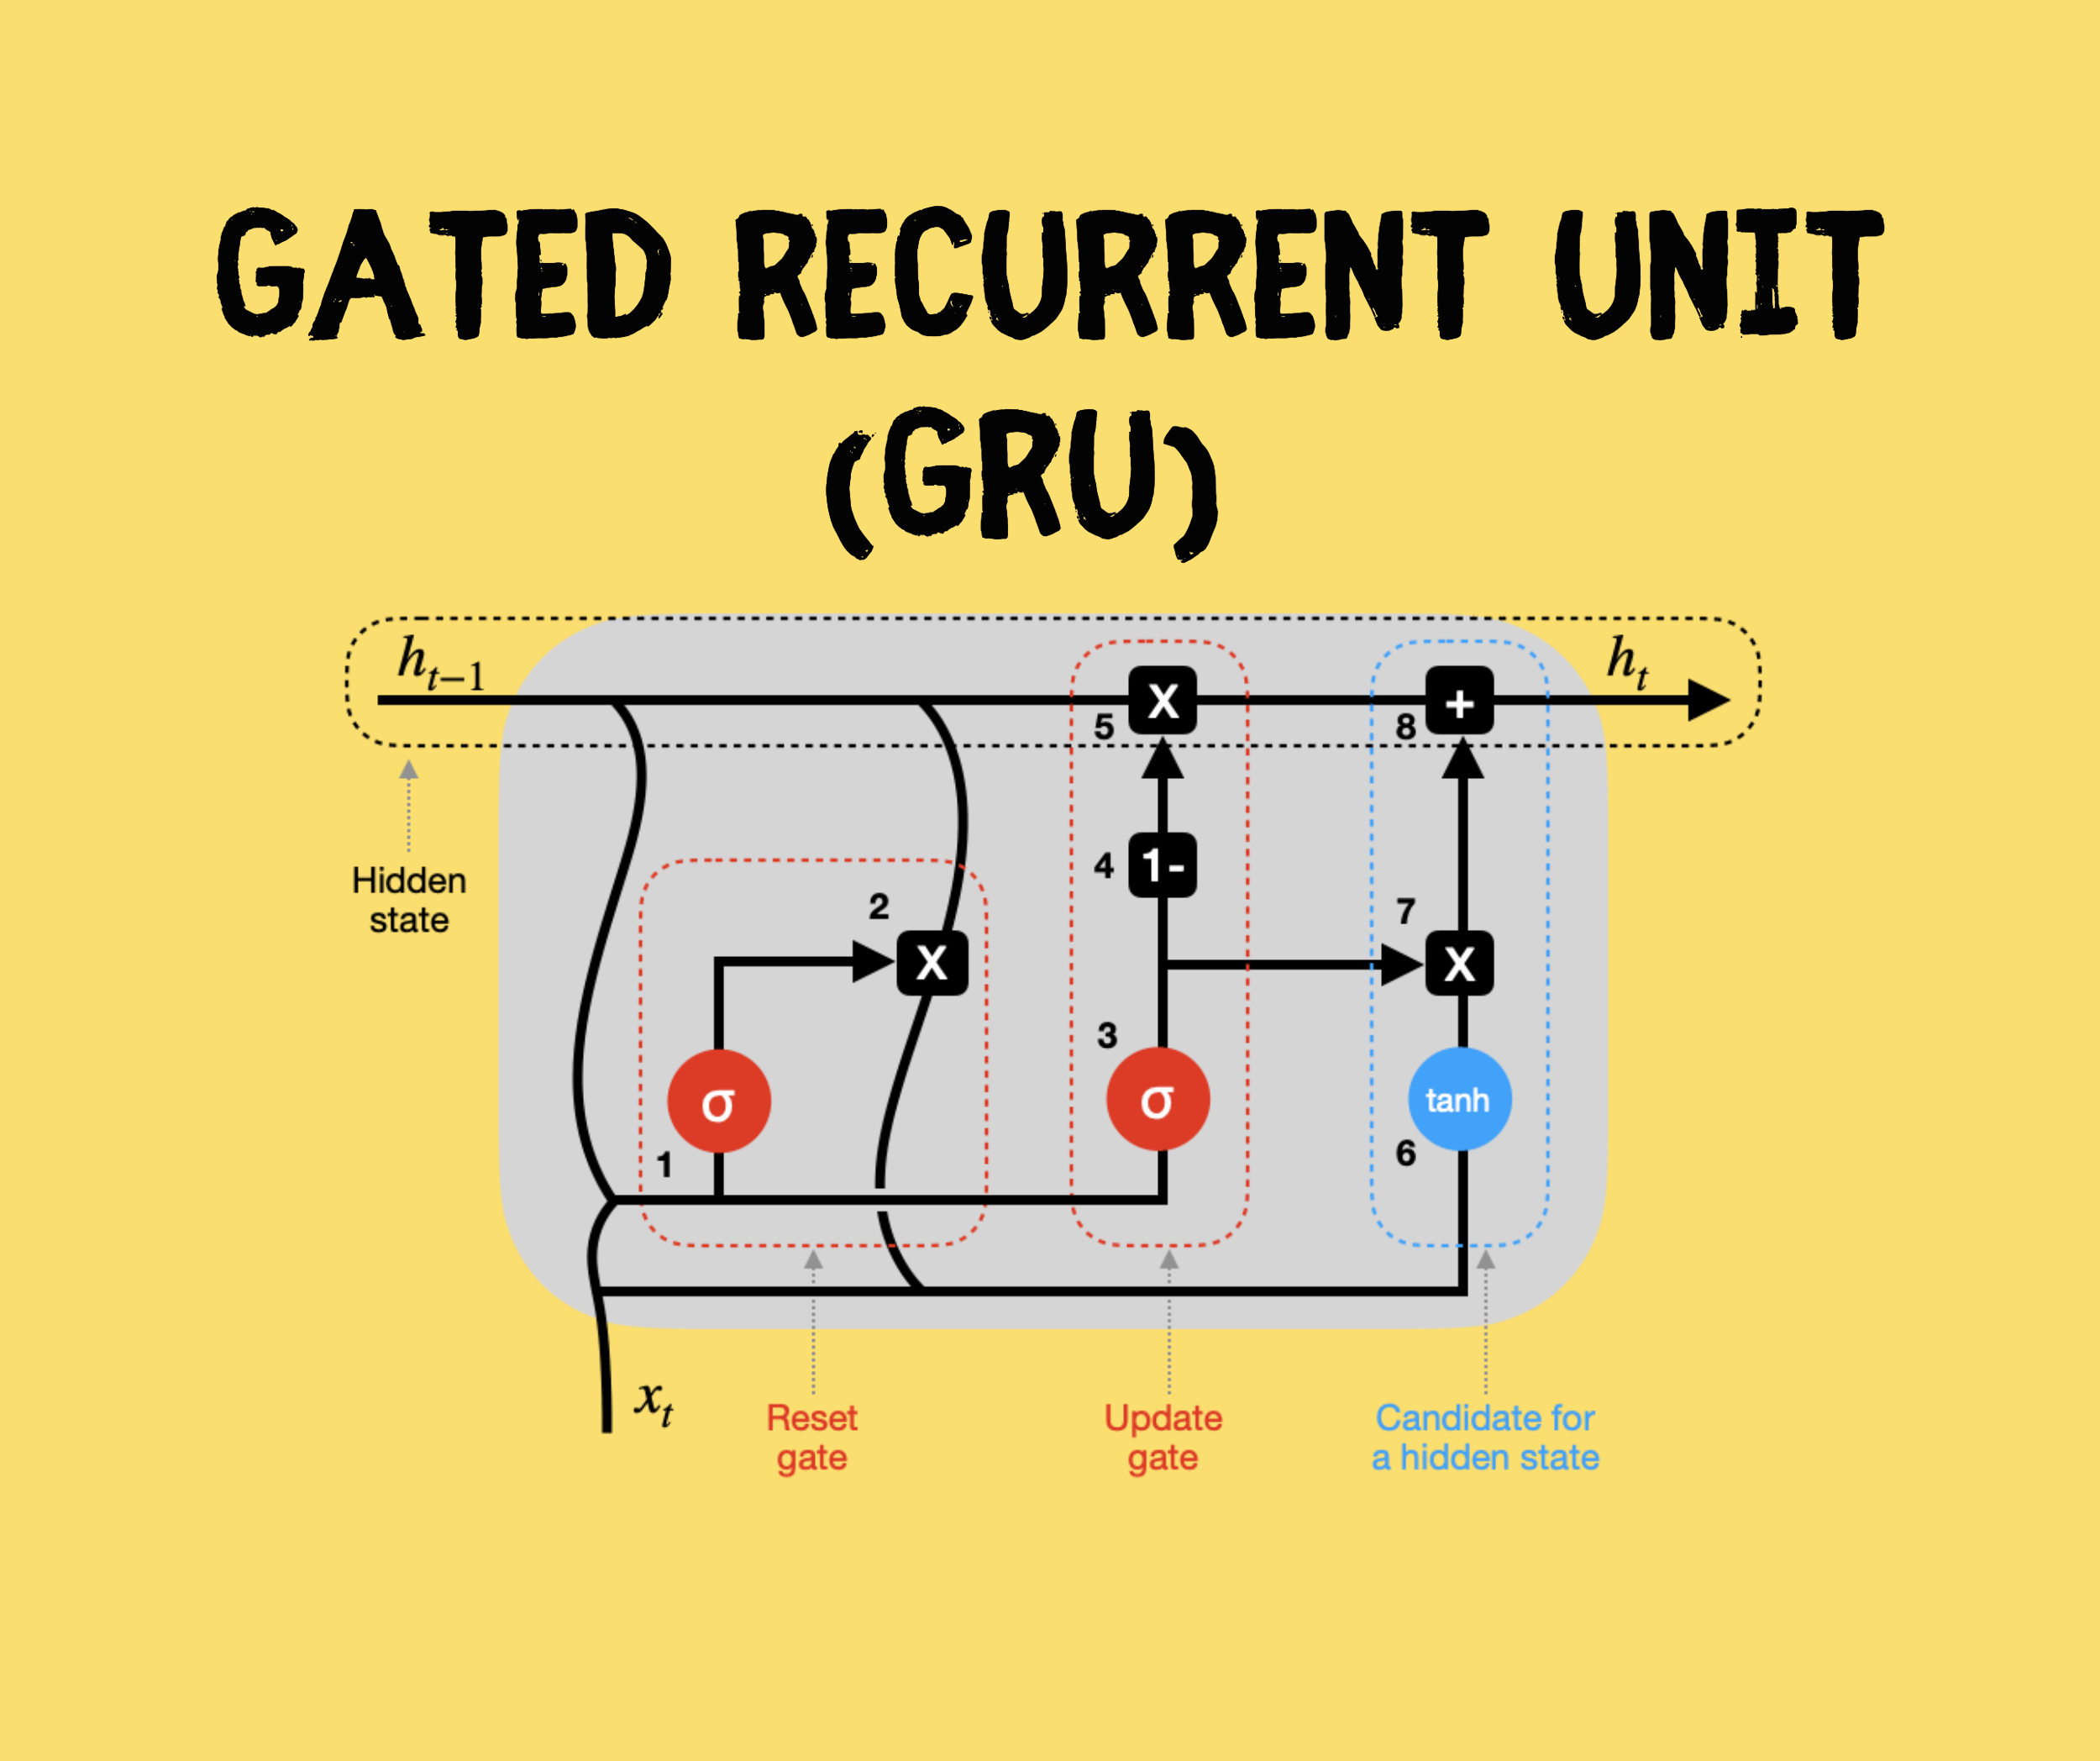

## 2. Data analysis

In [76]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import pickle
from collections import Counter
from matplotlib.patches import Patch

from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

In [2]:
raw_data = pd.read_csv('/content/drive/MyDrive/21 school/babynames-clean.csv', names=['name', 'gender'])

In [3]:
raw_data.head(5)

,name,gender
0,John,boy
1,William,boy
2,James,boy
3,Charles,boy
4,George,boy


In [4]:
raw_data['gender'].value_counts()

,count
gender,
boy,3437
girl,3345


Genders are pretty balanced

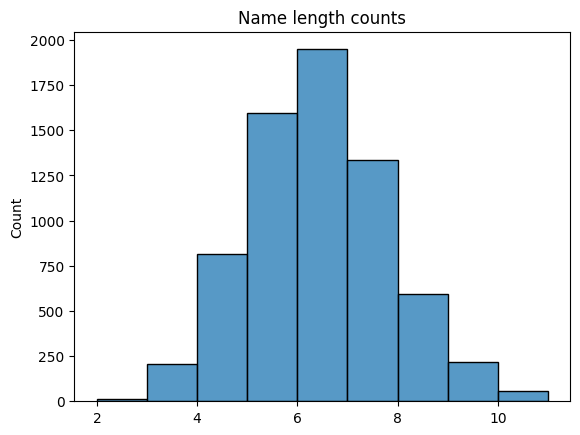

In [5]:
name_lengths = [len(name) for name in raw_data['name']]
sns.histplot(data=name_lengths, bins=range(2, 12))
plt.title('Name length counts')
plt.show()

Most of the name lengths lay around 6 letters

In [6]:
lst = [char for name in raw_data['name'] for char in name.lower()]
freq = pd.Series(lst).value_counts(normalize=True)
freq[:13]

,proportion
a,0.139109
e,0.125305
n,0.087649
i,0.081182
l,0.080958
r,0.076357
o,0.051510
t,0.043401
s,0.041636
d,0.038104


Most often occuring letters are A, E, N, I, L

## 3. Data preparation

In [7]:
def set_seed(seed=21):
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Random seed set to: {seed} (Reproducibility locked)")

In [8]:
set_seed()

Random seed set to: 21 (Reproducibility locked)


In [9]:
gender_encoder = LabelEncoder()
data = raw_data.copy()
data['gender'] = gender_encoder.fit_transform(data['gender'])
data['name'] = data['name'].apply(lambda x: x.lower())

In [10]:
special_tokens = ["<SOS>", "<EOS>", " "]
vocab = special_tokens + list(set(lst))
max_len = max(name_lengths) + 2

symbs_to_int = {char: idx for idx, char in enumerate(vocab)}
int_to_symbs = {idx: char for idx, char in enumerate(vocab)}

def process_and_encode(name, max_len, char_map):
    sos_token = "<SOS>"
    eos_token = "<EOS>"

    core_length = len(name) + 2
    pad_amount = max(0, max_len - core_length)
    padding_spaces = " " * (pad_amount // 2 + pad_amount % 2)

    token_sequence = list(" " * (pad_amount // 2)) + [sos_token] + list(name) + [eos_token] + list(padding_spaces)

    # token_sequence = [sos_token] + list(name) + [eos_token] + list(padding_spaces)

    token_sequence = token_sequence[:max_len]

    encoded_vector = [char_map[token] for token in token_sequence]

    return encoded_vector

encoded_series = data['name'].apply(lambda x: process_and_encode(x, max_len, symbs_to_int))

In [11]:
X = np.array([name for name in encoded_series])
y = data['gender'].to_numpy()

In [12]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=21)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, random_state=21)

In [13]:
class NamesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.Tensor(X)
        self.y = torch.Tensor(y)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, index):
        return (self.X[index], self.y[index])

In [14]:
train_set = NamesDataset(X_train, y_train)
val_set = NamesDataset(X_val, y_val)
test_set = NamesDataset(X_test, y_test)

train_loader = DataLoader(train_set, batch_size=1)
val_loader = DataLoader(val_set, batch_size=1)
test_loader = DataLoader(test_set, batch_size=1)

## 4. RNN

In [15]:
class VanillaRNN(nn.Module):
    def __init__(self, names_sizes, emb_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.names_sizes = names_sizes
        self.embedding = nn.Embedding(names_sizes, emb_dim)

        self.w_xh = nn.Linear(emb_dim, hidden_dim)
        self.w_hh = nn.Linear(hidden_dim, hidden_dim)

        self.next_token_fc = nn.Linear(hidden_dim, names_sizes)
        self.gender_fc = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(0.2)

    def init_hidden(self, batch_size=1):
        return torch.zeros(1, batch_size, self.hidden_dim)

    def forward(self, x, h=None):
        # x.shape: (seq_len, batch_size)
        x = self.embedding(x.long())

        if h is None:
            h = self.init_hidden(x.size(1))

        hidden_states = []
        for i in range(x.size(0)):
            h = torch.tanh(self.w_xh(x[i].unsqueeze(0)) + self.w_hh(h))
            hidden_states.append(h)

        all_h = torch.cat(hidden_states, dim=0)

        logits = self.next_token_fc(self.dropout(all_h))

        gender_logits = self.gender_fc(h.squeeze(0))

        return logits, gender_logits, h

In [16]:
def test_func(model, val_loader, criterion):
    model.eval()
    val_loss = 0
    val_batches = 0

    with torch.no_grad():
        for name, gender in val_loader:
            name = name[0]
            total_loss = 0

            h = model.init_hidden()

            for i in range(len(name) - 1):
                inputs = name[i].view(1, 1)
                target = name[i + 1].view(1).long()

                logits, _, h = model(inputs, h)
                step_loss = criterion(logits.view(1, -1), target)
                total_loss += step_loss

            total_loss = total_loss / (len(name) - 1)
            val_loss += total_loss.item()
            val_batches += 1

    avg_val_loss = val_loss / val_batches

    return avg_val_loss

In [17]:
def train_func(model, train_loader, val_loader, epochs, log_interval=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_loss, val_loss = [], []

    for epoch in range(epochs):
        running_loss = 0
        num_batches = 0

        for idx, (name, gender) in enumerate(train_loader):
            optimizer.zero_grad()

            name = name[0]
            total_loss = 0
            h = model.init_hidden()

            for i in range(len(name) - 1):
                inputs = name[i].view(1, 1)  # Shape: (seq_len=1, batch=1)
                target = name[i + 1].view(1).long()  # Shape: (1,)

                logits, _, h = model(inputs, h)
                step_loss = criterion(logits.view(1, -1), target)
                total_loss += step_loss

            total_loss = total_loss / (len(name) - 1)

            total_loss.backward()
            optimizer.step()

            running_loss += total_loss.item()
            num_batches += 1

            if idx % log_interval == 0:
                avg_loss = running_loss / (idx + 1)
                print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                    epoch, idx, len(train_loader.dataset),
                    100. * idx / len(train_loader), avg_loss))

        train_loss.append(running_loss / num_batches)
        val_loss.append(test_func(model, val_loader, criterion))

    return train_loss, val_loss

In [18]:
def name_generator(model, symbs_to_int, int_to_symbs, str_start="a", temperature=1.0, max_len=11):
    model.eval()
    with torch.no_grad():
        chars = [c for c in str_start]
        input_tensor = torch.tensor([symbs_to_int[c] for c in chars]).unsqueeze(1)  # Shape: (seq_len, batch_size=1)

        logits, _, h = model(input_tensor)

        generated_chars = chars.copy()

        for _ in range(max_len - len(str_start)):
            last_logits = logits[-1, 0, :]  # Shape: (vocab_size,)

            probs = F.softmax(last_logits / temperature, dim=-1)
            next_idx = torch.multinomial(probs, 1).item()

            if next_idx == symbs_to_int['<EOS>']:
                break

            if next_idx != symbs_to_int['<SOS>']:
                generated_chars.append(int_to_symbs[next_idx])

            next_tensor = torch.tensor([[next_idx]])
            logits, _, h = model(next_tensor, h)

        return "".join(generated_chars)

In [19]:
def test_gender_pred(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for names, genders in test_loader:
            for i in range(len(names)):
                name = names[i]
                gender = genders[i].item()

                h = model.init_hidden(batch_size=1)

                for j in range(len(name)):
                    input_tensor = name[j].view(1, 1)
                    _, _, h = model(input_tensor, h)

                try:
                    gender_logits = model.gender_fc(h.squeeze(0))
                except AttributeError:
                    gender_logits = model.gender_fc(h[0].squeeze(0))
                gender_prob = torch.sigmoid(gender_logits).item()

                all_preds.append(gender_prob)
                all_labels.append(gender)

    auc_score = roc_auc_score(all_labels, all_preds)

    return max(auc_score, 1 - auc_score)

In [20]:
def plot_loss_convergence(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    epochs = range(1, len(train_losses) + 1)

    plt.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2, marker='o', markersize=4)
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2, marker='s', markersize=4)

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train-Val Loss Convergence')

    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(fontsize=11)
    plt.ylim(bottom=min(min(train_losses), min(val_losses) if val_losses else 0) - 0.05)

    plt.tight_layout()
    plt.show()

In [ ]:
vanilla_model = VanillaRNN(len(vocab), max_len, 128)

In [ ]:
train_loss, val_loss = train_func(vanilla_model, train_loader, val_loader, 15, log_interval=2000)

Train Epoch: 0 [0/5425 (0%)]	Loss: 3.587090
Train Epoch: 0 [2000/5425 (37%)]	Loss: 1.505068
Train Epoch: 0 [4000/5425 (74%)]	Loss: 1.432018
Train Epoch: 1 [0/5425 (0%)]	Loss: 1.253719
Train Epoch: 1 [2000/5425 (37%)]	Loss: 1.293782
Train Epoch: 1 [4000/5425 (74%)]	Loss: 1.282573
Train Epoch: 2 [0/5425 (0%)]	Loss: 1.143812
Train Epoch: 2 [2000/5425 (37%)]	Loss: 1.249246
Train Epoch: 2 [4000/5425 (74%)]	Loss: 1.241765
Train Epoch: 3 [0/5425 (0%)]	Loss: 1.165161
Train Epoch: 3 [2000/5425 (37%)]	Loss: 1.222305
Train Epoch: 3 [4000/5425 (74%)]	Loss: 1.215102
Train Epoch: 4 [0/5425 (0%)]	Loss: 1.098491
Train Epoch: 4 [2000/5425 (37%)]	Loss: 1.200494
Train Epoch: 4 [4000/5425 (74%)]	Loss: 1.193989
Train Epoch: 5 [0/5425 (0%)]	Loss: 1.054293
Train Epoch: 5 [2000/5425 (37%)]	Loss: 1.182075
Train Epoch: 5 [4000/5425 (74%)]	Loss: 1.175833
Train Epoch: 6 [0/5425 (0%)]	Loss: 0.959286
Train Epoch: 6 [2000/5425 (37%)]	Loss: 1.168176
Train Epoch: 6 [4000/5425 (74%)]	Loss: 1.161616
Train Epoch: 7 [0/54

In [ ]:
start_strs = ['s', 'b', 'br', 'ak', 'm', 'la', 'pe', 'to', 'grk', 'plo']

for start_str in start_strs:
    temp_name = name_generator(vanilla_model, symbs_to_int, int_to_symbs, str_start=start_str, temperature=1, max_len=7)
    print(f'String start: {start_str} -> Result name: {temp_name}')

String start: s -> Result name: shin
String start: b -> Result name: bnorenc
String start: br -> Result name: brandia
String start: ak -> Result name: ak
String start: m -> Result name: mmichar
String start: la -> Result name: laurett
String start: pe -> Result name: pedemin
String start: to -> Result name: tondill
String start: grk -> Result name: grkenci
String start: plo -> Result name: plonath


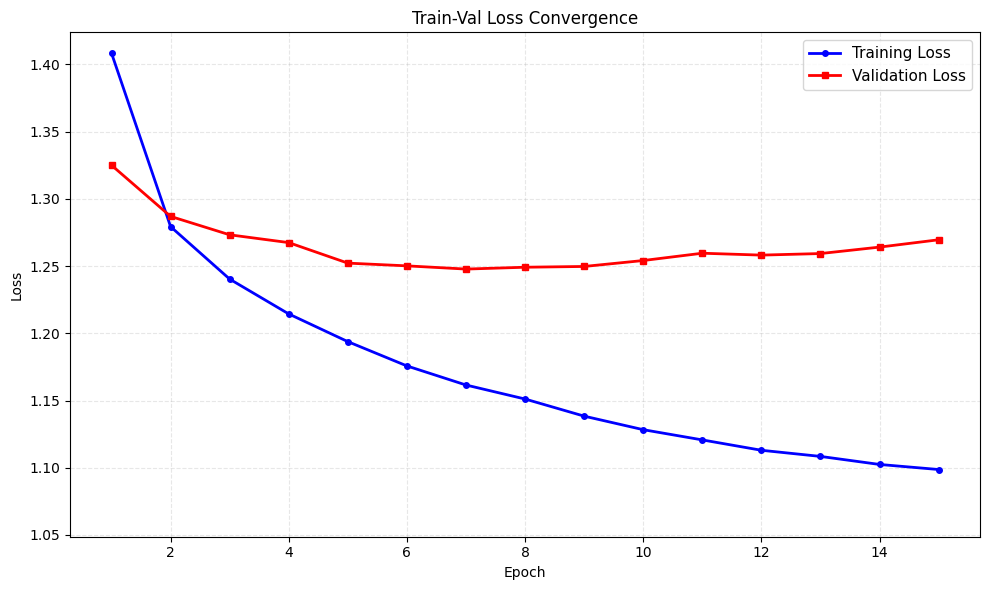

In [ ]:
plot_loss_convergence(train_loss, val_loss)

In [ ]:
print(test_gender_pred(vanilla_model, test_loader))

0.5821418036058235


## 5. Gated Recurrent Unit

In [21]:
class GRUModel(nn.Module):
    def __init__(self, names_sizes, emb_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.names_sizes = names_sizes

        self.embedding = nn.Embedding(names_sizes, emb_dim)

        # update gate
        self.w_z_x = nn.Linear(emb_dim, hidden_dim)
        self.w_z_h = nn.Linear(hidden_dim, hidden_dim)

        # reset gate
        self.w_r_x = nn.Linear(emb_dim, hidden_dim)
        self.w_r_h = nn.Linear(hidden_dim, hidden_dim)

        # hidden state
        self.w_h_x = nn.Linear(emb_dim, hidden_dim)
        self.w_h_h = nn.Linear(hidden_dim, hidden_dim)

        self.dropout = nn.Dropout(0.2)

        self.next_token_fc = nn.Linear(hidden_dim, names_sizes)
        self.gender_fc = nn.Linear(hidden_dim, 1)

    def init_hidden(self, batch_size=1):
        return torch.zeros(batch_size, self.hidden_dim)

    def forward(self, x, h=None):
        x = self.embedding(x.long())

        if h is None:
            h = self.init_hidden(x.size(1))

        hidden_states = []

        for i in range(x.size(0)):
            z_t = torch.sigmoid(self.w_z_x(x[i]) + self.w_z_h(h)) # update gate
            r_t = torch.sigmoid(self.w_r_x(x[i]) + self.w_r_h(h)) # reset gate

            h_t = torch.tanh(self.w_h_x(x[i]) + self.w_h_h(r_t * h)) # hidden state
            h = (1 - z_t) * h + z_t * h_t # Final hidden state

            hidden_states.append(h)

        all_h = torch.stack(hidden_states, dim=0)

        logits = self.next_token_fc(self.dropout(all_h))
        gender_logits = self.gender_fc(h)

        return logits, gender_logits, h

In [ ]:
gru_model = GRUModel(len(vocab), max_len, 128)

In [ ]:
train_loss, val_loss = train_func(gru_model, train_loader, val_loader, 15, log_interval=2000)

Train Epoch: 0 [0/5425 (0%)]	Loss: 3.424502
Train Epoch: 0 [2000/5425 (37%)]	Loss: 1.484584
Train Epoch: 0 [4000/5425 (74%)]	Loss: 1.410339
Train Epoch: 1 [0/5425 (0%)]	Loss: 1.136392
Train Epoch: 1 [2000/5425 (37%)]	Loss: 1.264337
Train Epoch: 1 [4000/5425 (74%)]	Loss: 1.249682
Train Epoch: 2 [0/5425 (0%)]	Loss: 1.096234
Train Epoch: 2 [2000/5425 (37%)]	Loss: 1.206099
Train Epoch: 2 [4000/5425 (74%)]	Loss: 1.194872
Train Epoch: 3 [0/5425 (0%)]	Loss: 1.041484
Train Epoch: 3 [2000/5425 (37%)]	Loss: 1.161212
Train Epoch: 3 [4000/5425 (74%)]	Loss: 1.152326
Train Epoch: 4 [0/5425 (0%)]	Loss: 1.008563
Train Epoch: 4 [2000/5425 (37%)]	Loss: 1.122648
Train Epoch: 4 [4000/5425 (74%)]	Loss: 1.115883
Train Epoch: 5 [0/5425 (0%)]	Loss: 0.954575
Train Epoch: 5 [2000/5425 (37%)]	Loss: 1.089740
Train Epoch: 5 [4000/5425 (74%)]	Loss: 1.083991
Train Epoch: 6 [0/5425 (0%)]	Loss: 0.922086
Train Epoch: 6 [2000/5425 (37%)]	Loss: 1.061816
Train Epoch: 6 [4000/5425 (74%)]	Loss: 1.056992
Train Epoch: 7 [0/54

In [ ]:
for start_str in start_strs:
    temp_name = name_generator(gru_model, symbs_to_int, int_to_symbs, str_start=start_str, temperature=1, max_len=7)
    print(f'String start: {start_str} -> Result name: {temp_name}')

String start: s -> Result name: shaw
String start: b -> Result name: beza
String start: br -> Result name: bralmi
String start: ak -> Result name: akhon
String start: m -> Result name: mabomya
String start: la -> Result name: laun
String start: pe -> Result name: perne
String start: to -> Result name: tolyn
String start: grk -> Result name: grkd
String start: plo -> Result name: plo


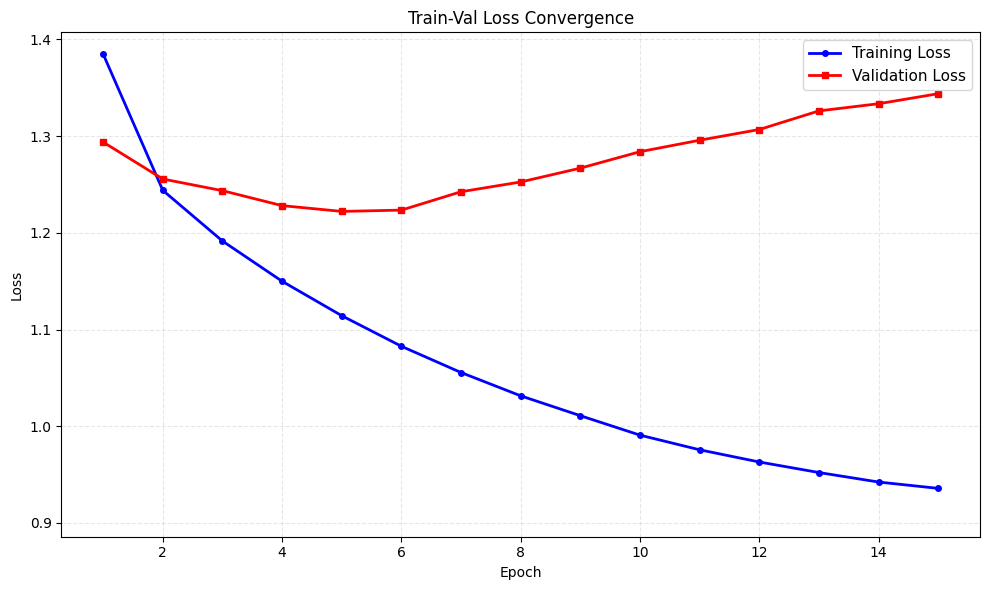

In [ ]:
plot_loss_convergence(train_loss, val_loss)

In [ ]:
print(test_gender_pred(gru_model, test_loader))

0.681531867636086


## 6. LSTM

In [22]:
class LSTMModel(nn.Module):
    def __init__(self, names_sizes, emb_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.names_sizes = names_sizes

        self.embedding = nn.Embedding(names_sizes, emb_dim)

        # input gate
        self.w_i_x = nn.Linear(emb_dim, hidden_dim)
        self.w_i_h = nn.Linear(hidden_dim, hidden_dim)

        # forget gate
        self.w_f_x = nn.Linear(emb_dim, hidden_dim)
        self.w_f_h = nn.Linear(hidden_dim, hidden_dim)

        # output gate
        self.w_o_x = nn.Linear(emb_dim, hidden_dim)
        self.w_o_h = nn.Linear(hidden_dim, hidden_dim)

        self.w_c_x = nn.Linear(emb_dim, hidden_dim)
        self.w_c_h = nn.Linear(hidden_dim, hidden_dim)

        self.dropout = nn.Dropout(0.2)

        self.next_token_fc = nn.Linear(hidden_dim, names_sizes)
        self.gender_fc = nn.Linear(hidden_dim, 1)

    def init_hidden(self, batch_size=1):
        h = torch.zeros(batch_size, self.hidden_dim)
        c = torch.zeros(batch_size, self.hidden_dim)
        return h, c

    def forward(self, x, state=None):
        x = self.embedding(x.long())

        if state is None:
            h, c = self.init_hidden(x.size(1))
        else:
            h, c = state

        hidden_states = []

        for i in range(x.size(0)):
            i_t = torch.sigmoid(self.w_i_x(x[i]) + self.w_i_h(h)) # input gate
            f_t = torch.sigmoid(self.w_f_x(x[i]) + self.w_f_h(h)) # forget gate
            o_t = torch.sigmoid(self.w_o_x(x[i]) + self.w_o_h(h)) # output gate

            c_tilde = torch.tanh(self.w_c_x(x[i]) + self.w_c_h(h))
            c = f_t * c + i_t * c_tilde
            h = o_t * torch.tanh(c)

            hidden_states.append(h)

        all_h = torch.stack(hidden_states, dim=0)

        logits = self.next_token_fc(self.dropout(all_h))
        gender_logits = self.gender_fc(h)

        return logits, gender_logits, (h, c)

In [ ]:
lstm_model = LSTMModel(len(vocab), max_len, 128)

In [ ]:
train_loss, val_loss = train_func(lstm_model, train_loader, val_loader, 15, log_interval=2000)

Train Epoch: 0 [0/5425 (0%)]	Loss: 3.360140
Train Epoch: 0 [2000/5425 (37%)]	Loss: 1.493177
Train Epoch: 0 [4000/5425 (74%)]	Loss: 1.416611
Train Epoch: 1 [0/5425 (0%)]	Loss: 1.158350
Train Epoch: 1 [2000/5425 (37%)]	Loss: 1.268305
Train Epoch: 1 [4000/5425 (74%)]	Loss: 1.252991
Train Epoch: 2 [0/5425 (0%)]	Loss: 1.077455
Train Epoch: 2 [2000/5425 (37%)]	Loss: 1.207215
Train Epoch: 2 [4000/5425 (74%)]	Loss: 1.196128
Train Epoch: 3 [0/5425 (0%)]	Loss: 0.958042
Train Epoch: 3 [2000/5425 (37%)]	Loss: 1.163249
Train Epoch: 3 [4000/5425 (74%)]	Loss: 1.154059
Train Epoch: 4 [0/5425 (0%)]	Loss: 0.895695
Train Epoch: 4 [2000/5425 (37%)]	Loss: 1.127041
Train Epoch: 4 [4000/5425 (74%)]	Loss: 1.118276
Train Epoch: 5 [0/5425 (0%)]	Loss: 0.876644
Train Epoch: 5 [2000/5425 (37%)]	Loss: 1.094370
Train Epoch: 5 [4000/5425 (74%)]	Loss: 1.086516
Train Epoch: 6 [0/5425 (0%)]	Loss: 0.896058
Train Epoch: 6 [2000/5425 (37%)]	Loss: 1.064259
Train Epoch: 6 [4000/5425 (74%)]	Loss: 1.058030
Train Epoch: 7 [0/54

In [ ]:
for start_str in start_strs:
    temp_name = name_generator(lstm_model, symbs_to_int, int_to_symbs, str_start=start_str, temperature=1, max_len=7)
    print(f'String start: {start_str} -> Result name: {temp_name}')

String start: s -> Result name: stah
String start: b -> Result name: berto
String start: br -> Result name: brah
String start: ak -> Result name: ak
String start: m -> Result name: marr
String start: la -> Result name: laussk
String start: pe -> Result name: pes
String start: to -> Result name: ton
String start: grk -> Result name: grkenzi
String start: plo -> Result name: plopina


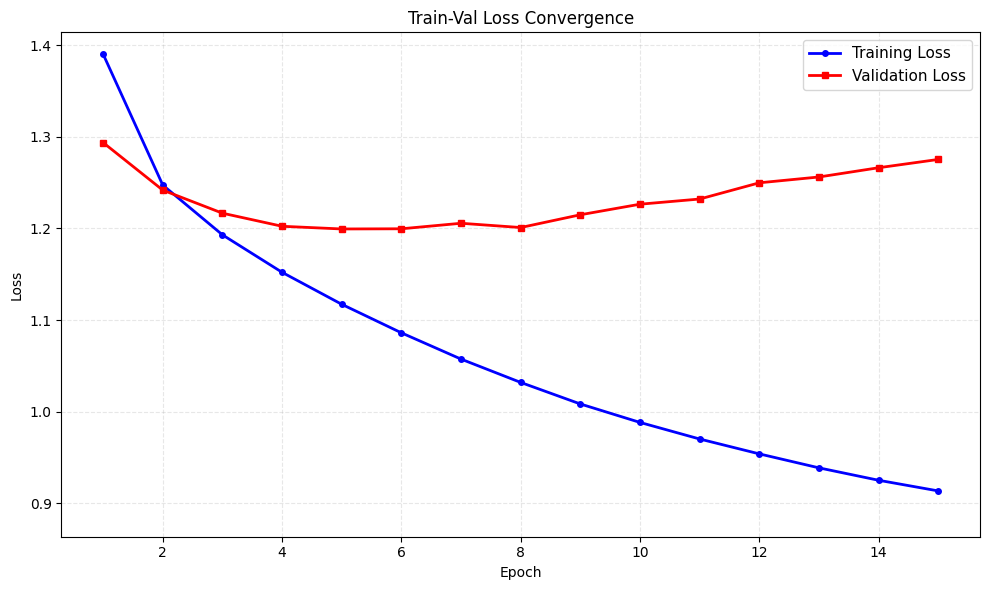

In [ ]:
plot_loss_convergence(train_loss, val_loss)

In [ ]:
print(test_gender_pred(lstm_model, test_loader))

0.5050018219993406


## 7. Model comparison

My metric is based on bulding a markov chain for all the names in the dataset, then for a each letter $l_{i}$ in the generated name we summ up all the probabilities in the chain of going from $l_{i}$ to $l_{i+1}$ and then dividing them by the number of letters in the word.
$$metric = \frac{\sum_{i}^{n}p(l_{i+1}|l_{i})}{n}$$
It can also be modified by taking our model's confidence, so the resulting metric will be
$$metric = \frac{1}{2}(\frac{\sum_{i}^{n}p(l_{i+1}|l_{i})}{n} + e^{-loss})$$

Perplexity measures how sure is the model, when predicting the next token, so for example: if the tokens before were 'Andr' and the model has three variants: 'e' - 75%, 'y' - 15% and 'a' - 10%, perplexity is high, because the model is mostly sure what comes next, but if there are 20 letters, each with a probability of 5%, perplexity is low because the guess is purely random.

Perplexity is defined as the inverse probability of the test set, normalized by the number of tokens:
$$perplexity(w)=P(w_{1}​,w_{2}​,...,w_{n}​)^{−1/n}$$
$$P(w_{1}​,w_{2}​,...,w_{n}​)^{-1/n}=(\prod_{i=1}^{n}​P(w_{i}​∣w_{1}​,...,w_{i−1}​))^{-1/n}$$
$$ln(perplexity(w))=-\frac{1}{n}\sum_{i=1}^{n}​P(w_{i}​∣w_{1}​,...,w_{i−1}​)$$
And the cross-entropy loss is:
$$cross-entropy-loss(w)=-\frac{1}{n}\sum_{i=1}^{n}​P(w_{i}​∣w_{1}​,...,w_{i−1}​)$$


In [ ]:
def perplexity_cross_ent(model, name):
    model.eval()
    total_loss = 0
    h = model.init_hidden()

    with torch.no_grad():
        for i in range(len(name) - 1):
            current_char = name[i].view(1, 1)
            target_char = name[i + 1].view(1)

            logits, _, h = model(current_char, h)

            loss = F.cross_entropy(logits.view(1, -1), target_char)
            total_loss += loss.item()

    avg_loss = total_loss / (len(name) - 1)
    perplexity = 2 ** avg_loss

    return perplexity

In [ ]:
def perplexity_no_cross_ent(model, name):
    model.eval()
    total_loss = 0
    h = model.init_hidden()
    probabilities = []

    with torch.no_grad():
        for i in range(len(name) - 1):
            current_char = name[i].view(1, 1)
            target_char = name[i + 1].view(1)

            logits, _, h = model(current_char, h)

            probs = F.softmax(logits, dim=-1)

            correct_prob = probs[name[i]].item()
            correct_prob = max(correct_prob, 1e-10)

            probabilities.append(correct_prob)

    neg_log_probs = [-np.log(p) for p in probabilities]
    avg_neg_log_prob = np.mean(neg_log_probs)
    perplexity = np.exp(avg_neg_log_prob)

    return perplexity

If the number of letters is n the probability of each letter is
$$P(w)=\frac{1}{n}$$
the probability of model assigning correct character is $p=\frac{1}{n}$
the cross-entropy is then
$$cross-entropy=\frac{1}{n}n(-ln(\frac{1}{n}))$$
$$cross-entropy=ln(n)$$
so perplexity will be
$$perplexity=e^{ln(n)}=n$$

In [ ]:
class RandomModel(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.logits = torch.full((n,), 1/n)

    def init_hidden(self, batch_size=1):
        return None

    def forward(self, x, h=None):
        return self.logits, None, h

In [ ]:
test_model = RandomModel(15)
name = torch.randint(0, 14, (11,))
res_score = perplexity_no_cross_ent(test_model, name)
print(f'Resulting score of random model: {res_score:.5}')

Resulting score of random model: 15.0


In [ ]:
class MostPopularModel(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.logits = torch.zeros(n)
        self.num_letters = 0

    def init_hidden(self, batch_size=1):
        return None

    def forward(self, x, h=None):
        self.logits *= self.num_letters
        self.num_letters += 1
        self.logits[x.item()] += 1
        self.logits = self.logits / self.num_letters

        return self.logits, None, h

In [ ]:
test_model = MostPopularModel(15)
res_score = perplexity_no_cross_ent(test_model, name)
print(f'Resulting score of most frequent model model: {res_score:.5}')

Resulting score of most frequent model model: 11.82


The results of both of this test models are mostly the same on a random word. But there is the difference in that the "most frequent model" can show better results in the words where one letter prevails over the other, and worse results in the words that consist of mostly non-repeating letters.

In [ ]:
for start_str in start_strs:
    temp_name = name_generator(vanilla_model, symbs_to_int, int_to_symbs, str_start=start_str, temperature=1, max_len=11)
    temp_name_tens = torch.tensor(list(map(symbs_to_int.get, temp_name)))
    print(f'name: {temp_name} - {perplexity_cross_ent(vanilla_model, temp_name_tens):5f}')

name: sydr - 3.904651
name: brodfasto - 3.638748
name: broddama - 2.383684
name: akialdenoce - 2.748743
name: minggingiel - 3.458791
name: lamishani - 3.441980
name: penvera - 7.746251
name: tonfipe - 2.885282
name: grkencero - 5.724128
name: plomansey - 4.832186


In [ ]:
for start_str in start_strs:
    temp_name = name_generator(gru_model, symbs_to_int, int_to_symbs, str_start=start_str, temperature=1, max_len=11)
    temp_name_tens = torch.tensor(list(map(symbs_to_int.get, temp_name)))
    print(f'name: {temp_name} - {perplexity_cross_ent(gru_model, temp_name_tens):5f}')

name: ssia - 3.720541
name: bertz - 2.846749
name: brelmina - 7.256356
name: akall - 4.730448
name: mussarod - 3.016758
name: lam - 5.907204
name: pentenita - 2.653104
name: tonya - 2.009857
name: grk - 173.793598
name: plos - 9.492756


In [ ]:
for start_str in start_strs:
    temp_name = name_generator(lstm_model, symbs_to_int, int_to_symbs, str_start=start_str, temperature=1, max_len=11)
    temp_name_tens = torch.tensor(list(map(symbs_to_int.get, temp_name)))
    print(f'name: {temp_name} - {perplexity_cross_ent(lstm_model, temp_name_tens):5f}')

name: swevon - 5.880908
name: blenandella - 2.776680
name: bratciolleo - 3.910668
name: ak - 19.575891
name: med - 2.672156
name: lausquflill - 3.025517
name: per - 3.980580
name: tom - 6.113459
name: grkouda - 16.893491
name: ploderarahk - 3.945592


## 8. Gender classification

In [ ]:
def train_func(model, train_loader, val_loader, epochs, log_interval=10):
    gender_criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_loss, val_loss = [], []

    for epoch in range(epochs):
        running_loss = 0
        num_batches = 0

        for idx, (name, gender) in enumerate(train_loader):
            optimizer.zero_grad()

            name = name[0]
            gender_target = gender.float().view(1, 1)
            h = model.init_hidden()

            for i in range(len(name) - 1):
                inputs = name[i].view(1, 1)
                _, gender_logits, h = model(inputs, h)

            total_loss = gender_criterion(gender_logits, gender_target)

            total_loss.backward()
            optimizer.step()

            running_loss += total_loss.item()
            num_batches += 1

            if idx % log_interval == 0:
                avg_loss = running_loss / (idx + 1)
                print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                    epoch, idx, len(train_loader.dataset),
                    100. * idx / len(train_loader), avg_loss))

        train_loss.append(running_loss / num_batches)

        val_loss.append(test_func(model, val_loader, gender_criterion))

    return train_loss, val_loss

In [ ]:
def test_func_nll(model, val_loader, criterion):
    model.eval()
    val_loss = 0
    val_batches = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for name, gender in val_loader:
            gender_target = gender.long().view(1)
            h = model.init_hidden()
            name = name[0]

            for i in range(len(name) - 1):
                inputs = name[i].view(1, 1)
                _, gender_outputs, h = model(inputs, h)
                gender_outputs = torch.log_softmax(gender_outputs, dim=-1)

            loss = criterion(gender_outputs, gender_target)

            val_loss += loss.item()
            val_batches += 1

    avg_val_loss = val_loss / val_batches

    return avg_val_loss

In [ ]:
def train_func_nll(model, train_loader, val_loader, epochs, log_interval=10):
    gender_criterion = nn.NLLLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    model.gender_fc = nn.Linear(model.hidden_dim, 2)

    train_loss, val_loss = [], []

    for epoch in range(epochs):
        running_loss = 0
        num_batches = 0

        for idx, (name, gender) in enumerate(train_loader):
            optimizer.zero_grad()

            name = name[0]
            gender_target = gender.long().view(1)
            h = model.init_hidden()

            for i in range(len(name) - 1):
                inputs = name[i].view(1, 1)
                _, gender_logits, h = model(inputs, h)
                gender_logits = torch.log_softmax(gender_logits, dim=-1)

            total_loss = gender_criterion(gender_logits, gender_target)

            total_loss.backward()
            optimizer.step()

            running_loss += total_loss.item()
            num_batches += 1

            if idx % log_interval == 0:
                avg_loss = running_loss / (idx + 1)
                print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                    epoch, idx, len(train_loader.dataset),
                    100. * idx / len(train_loader), avg_loss))

        train_loss.append(running_loss / num_batches)

        val_loss.append(test_func_nll(model, val_loader, gender_criterion))

    return train_loss, val_loss

In [ ]:
def test_func(model, val_loader, criterion):
    model.eval()
    val_loss = 0
    val_batches = 0

    with torch.no_grad():
        for name, gender in val_loader:
            name = name[0]
            total_loss = 0
            gender_target = gender.float().view(1, 1)
            h = model.init_hidden()

            for i in range(len(name) - 1):
                inputs = name[i].view(1, 1)
                target = name[i + 1]

                _, gender_logits, h = model(inputs, h)
                step_loss = criterion(gender_logits, gender_target)
                total_loss += step_loss

            total_loss = total_loss / (len(name) - 1)
            val_loss += total_loss.item()
            val_batches += 1

    avg_val_loss = val_loss / val_batches

    return avg_val_loss

In [ ]:
vanilla_model = VanillaRNN(len(vocab), max_len, 128)
train_loss, val_loss = train_func(vanilla_model, train_loader, val_loader, 15, log_interval=10000)

Train Epoch: 0 [0/5425 (0%)]	Loss: 0.561224
Train Epoch: 1 [0/5425 (0%)]	Loss: 0.352567
Train Epoch: 2 [0/5425 (0%)]	Loss: 0.367608
Train Epoch: 3 [0/5425 (0%)]	Loss: 0.189980
Train Epoch: 4 [0/5425 (0%)]	Loss: 0.340240
Train Epoch: 5 [0/5425 (0%)]	Loss: 0.636812
Train Epoch: 6 [0/5425 (0%)]	Loss: 0.230970
Train Epoch: 7 [0/5425 (0%)]	Loss: 0.253154
Train Epoch: 8 [0/5425 (0%)]	Loss: 0.426978
Train Epoch: 9 [0/5425 (0%)]	Loss: 0.259892
Train Epoch: 10 [0/5425 (0%)]	Loss: 0.623279
Train Epoch: 11 [0/5425 (0%)]	Loss: 0.276615
Train Epoch: 12 [0/5425 (0%)]	Loss: 1.291850
Train Epoch: 13 [0/5425 (0%)]	Loss: 0.216893
Train Epoch: 14 [0/5425 (0%)]	Loss: 0.309689


In [ ]:
for start_str in start_strs:
    temp_name = name_generator(vanilla_model, symbs_to_int, int_to_symbs, str_start=start_str, temperature=1, max_len=7)
    print(f'String start: {start_str} -> Result name: {temp_name}')

String start: s -> Result name: swpzhbt
String start: b -> Result name: bnluvjs
String start: br -> Result name: brpsrkp
String start: ak -> Result name: akxswr
String start: m -> Result name: mwsllvo
String start: la -> Result name: lapig
String start: pe -> Result name: pehmypy
String start: to -> Result name: toqgm b
String start: grk -> Result name: grkkddo
String start: plo -> Result name: ploxta


In [ ]:
test_gender_pred(vanilla_model, val_loader)

np.float64(0.8731260628788209)

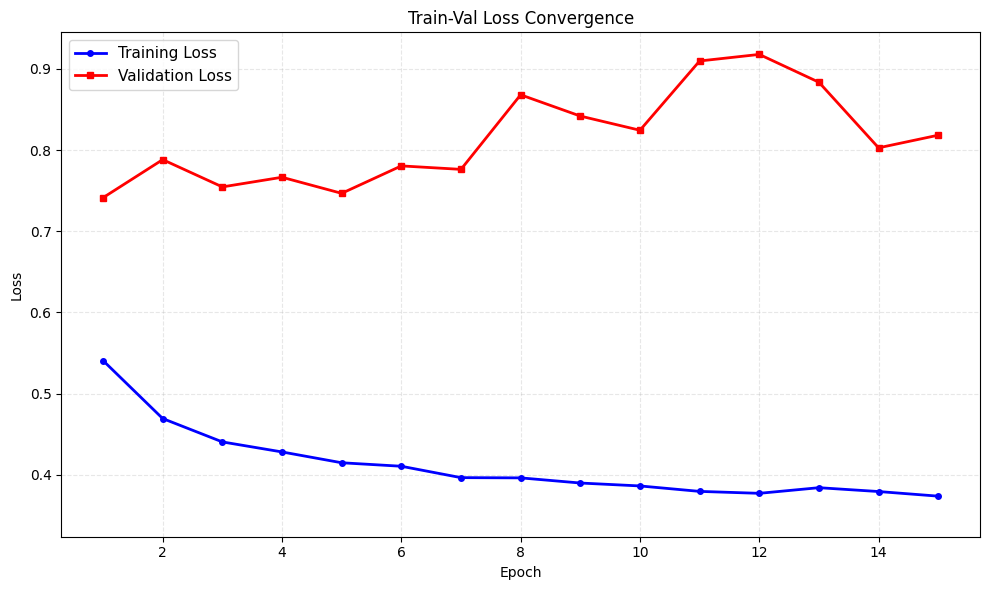

In [ ]:
plot_loss_convergence(train_loss, val_loss)

In [ ]:
vanilla_model = VanillaRNN(len(vocab), max_len, 128)
train_loss, val_loss = train_func_nll(vanilla_model, train_loader, val_loader, 15, log_interval=10000)

Train Epoch: 0 [0/5425 (0%)]	Loss: 0.427074
Train Epoch: 1 [0/5425 (0%)]	Loss: 0.176781
Train Epoch: 2 [0/5425 (0%)]	Loss: 0.141262
Train Epoch: 3 [0/5425 (0%)]	Loss: 0.367970
Train Epoch: 4 [0/5425 (0%)]	Loss: 0.534133
Train Epoch: 5 [0/5425 (0%)]	Loss: 0.348514
Train Epoch: 6 [0/5425 (0%)]	Loss: 0.158998
Train Epoch: 7 [0/5425 (0%)]	Loss: 0.282807
Train Epoch: 8 [0/5425 (0%)]	Loss: 0.211091
Train Epoch: 9 [0/5425 (0%)]	Loss: 0.075307
Train Epoch: 10 [0/5425 (0%)]	Loss: 0.235942
Train Epoch: 11 [0/5425 (0%)]	Loss: 0.099747
Train Epoch: 12 [0/5425 (0%)]	Loss: 0.098657
Train Epoch: 13 [0/5425 (0%)]	Loss: 0.219536
Train Epoch: 14 [0/5425 (0%)]	Loss: 0.121369


In [ ]:
for start_str in start_strs:
    temp_name = name_generator(vanilla_model, symbs_to_int, int_to_symbs, str_start=start_str, temperature=1, max_len=7)
    print(f'String start: {start_str} -> Result name: {temp_name}')

String start: s -> Result name: sbegpem
String start: b -> Result name: bshjxpw
String start: br -> Result name: brcc zr
String start: ak -> Result name: aksxws
String start: m -> Result name: mr yngw
String start: la -> Result name: laamvmw
String start: pe -> Result name: pebzak
String start: to -> Result name: toad 
String start: grk -> Result name: grkdzpz
String start: plo -> Result name: ploxiz


In [ ]:
def test_gender_pred_nll(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for names, genders in test_loader:
            for i in range(len(names)):
                name = names[i]
                gender = genders[i].item()

                h = model.init_hidden(batch_size=1)

                for j in range(len(name)):
                    input_tensor = name[j].view(1, 1)
                    _, gender_outputs, h = model(input_tensor, h)

                prob_class_1 = torch.softmax(gender_outputs, dim=-1)[0, 1].item()

                all_preds.append(prob_class_1)
                all_labels.append(gender)

    auc_score = roc_auc_score(all_labels, all_preds)

    return max(auc_score, 1 - auc_score)


In [ ]:
test_gender_pred_nll(vanilla_model, val_loader)

np.float64(0.8851262372999606)

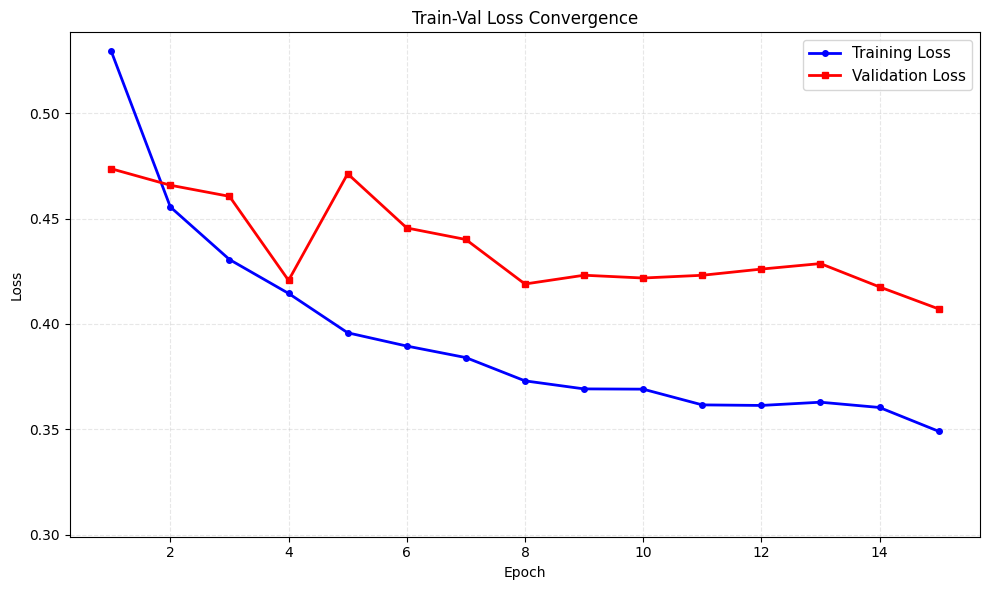

In [ ]:
plot_loss_convergence(train_loss, val_loss)

In [ ]:
gru_model = GRUModel(len(vocab), max_len, 128)
train_loss, val_loss = train_func(gru_model, train_loader, val_loader, 15, log_interval=10000)

Train Epoch: 0 [0/5425 (0%)]	Loss: 0.487940
Train Epoch: 1 [0/5425 (0%)]	Loss: 0.316137
Train Epoch: 2 [0/5425 (0%)]	Loss: 0.261691
Train Epoch: 3 [0/5425 (0%)]	Loss: 0.157392
Train Epoch: 4 [0/5425 (0%)]	Loss: 0.065693
Train Epoch: 5 [0/5425 (0%)]	Loss: 0.055005
Train Epoch: 6 [0/5425 (0%)]	Loss: 0.064999
Train Epoch: 7 [0/5425 (0%)]	Loss: 0.022788
Train Epoch: 8 [0/5425 (0%)]	Loss: 0.003887
Train Epoch: 9 [0/5425 (0%)]	Loss: 0.003550
Train Epoch: 10 [0/5425 (0%)]	Loss: 0.023318
Train Epoch: 11 [0/5425 (0%)]	Loss: 0.003452
Train Epoch: 12 [0/5425 (0%)]	Loss: 0.000369
Train Epoch: 13 [0/5425 (0%)]	Loss: 0.000882
Train Epoch: 14 [0/5425 (0%)]	Loss: 0.000136


In [ ]:
for start_str in start_strs:
    temp_name = name_generator(gru_model, symbs_to_int, int_to_symbs, str_start=start_str, temperature=1, max_len=7)
    print(f'String start: {start_str} -> Result name: {temp_name}')

String start: s -> Result name: s
String start: b -> Result name: bmciikj
String start: br -> Result name: brglxnm
String start: ak -> Result name: akcfvib
String start: m -> Result name: mjfnrd
String start: la -> Result name: lalohhc
String start: pe -> Result name: peaylvo
String start: to -> Result name: tooyhpn
String start: grk -> Result name: grkrimh
String start: plo -> Result name: plox p


In [ ]:
test_gender_pred(gru_model, val_loader)

np.float64(0.8819604936118257)

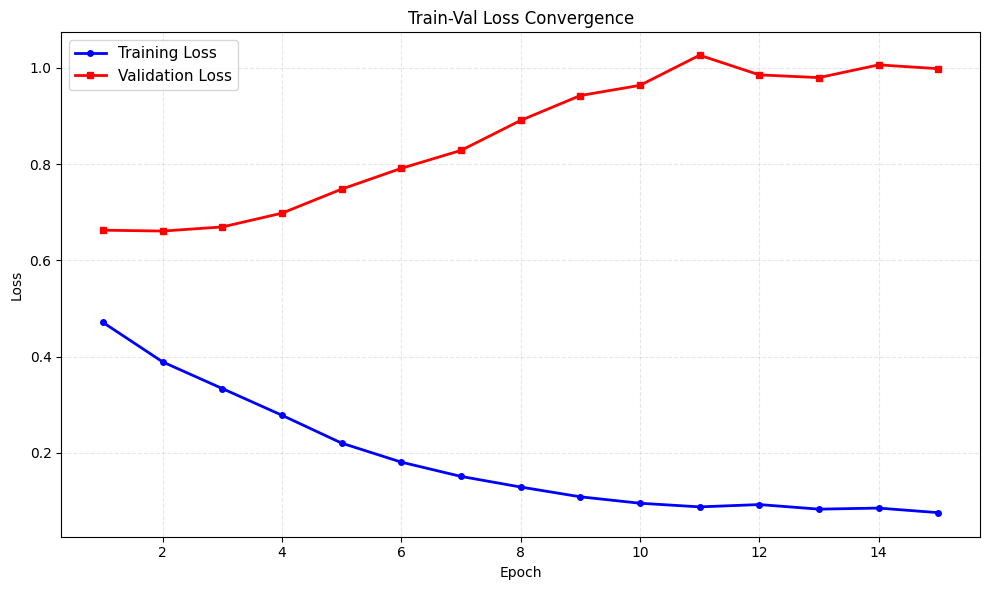

In [ ]:
plot_loss_convergence(train_loss, val_loss)

In [ ]:
lstm_model = LSTMModel(len(vocab), max_len, 128)
train_loss, val_loss = train_func(lstm_model, train_loader, val_loader, 15, log_interval=10000)

Train Epoch: 0 [0/5425 (0%)]	Loss: 0.703385
Train Epoch: 1 [0/5425 (0%)]	Loss: 0.444668
Train Epoch: 2 [0/5425 (0%)]	Loss: 0.430186
Train Epoch: 3 [0/5425 (0%)]	Loss: 0.311010
Train Epoch: 4 [0/5425 (0%)]	Loss: 0.228134
Train Epoch: 5 [0/5425 (0%)]	Loss: 0.172949
Train Epoch: 6 [0/5425 (0%)]	Loss: 0.123376
Train Epoch: 7 [0/5425 (0%)]	Loss: 0.121829
Train Epoch: 8 [0/5425 (0%)]	Loss: 0.050045
Train Epoch: 9 [0/5425 (0%)]	Loss: 0.075355
Train Epoch: 10 [0/5425 (0%)]	Loss: 0.029366
Train Epoch: 11 [0/5425 (0%)]	Loss: 0.005908
Train Epoch: 12 [0/5425 (0%)]	Loss: 0.111524
Train Epoch: 13 [0/5425 (0%)]	Loss: 0.003392
Train Epoch: 14 [0/5425 (0%)]	Loss: 0.000222


In [ ]:
for start_str in start_strs:
    temp_name = name_generator(lstm_model, symbs_to_int, int_to_symbs, str_start=start_str, temperature=1, max_len=7)
    print(f'String start: {start_str} -> Result name: {temp_name}')

String start: s -> Result name: sgqw
String start: b -> Result name: beuzdpy
String start: br -> Result name: brkvjyn
String start: ak -> Result name: ak csvj
String start: m -> Result name: mtfhlc 
String start: la -> Result name: ladkapb
String start: pe -> Result name: peanezo
String start: to -> Result name: toz
String start: grk -> Result name: grkdrly
String start: plo -> Result name: plokgon


In [ ]:
test_gender_pred(lstm_model, val_loader)

np.float64(0.871111498713644)

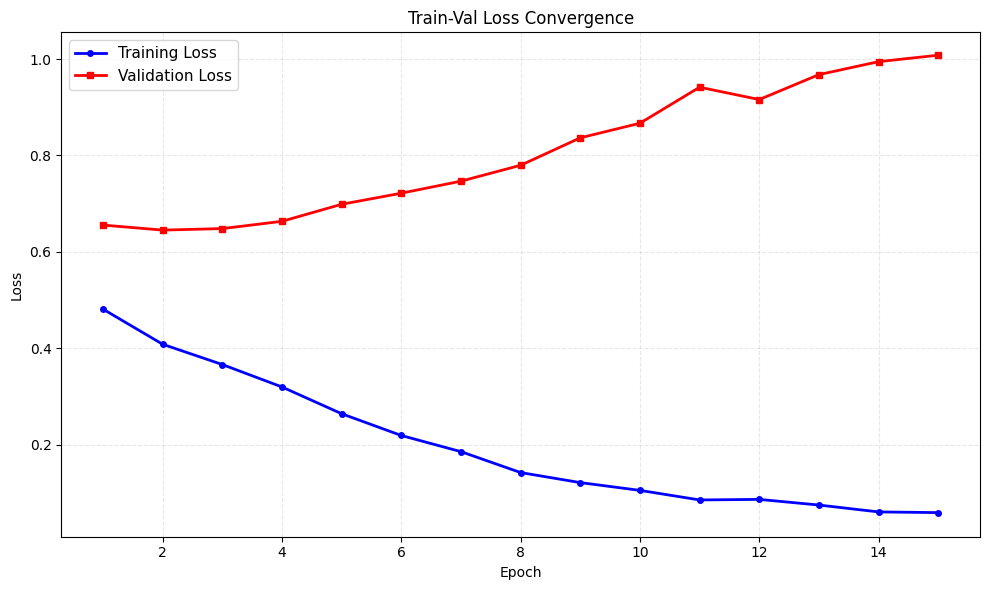

In [ ]:
plot_loss_convergence(train_loss, val_loss)

## 9.Vanishing Gradient

In [ ]:
mode_length = Counter(name_lengths).most_common(1)[0][0]
filtered = pd.Series([name.lower() for name in raw_data['name'] if len(name) == mode_length])
y = pd.Series([0 for i in range(len(filtered))])
encoded_series = filtered.apply(lambda x: process_and_encode(x, max_len, symbs_to_int))

In [ ]:
grad_test_set = NamesDataset(np.array([name for name in encoded_series]), y.to_numpy())
grad_test_loader = DataLoader(grad_test_set, batch_size=1)

In [ ]:
name_tens, _ = next(iter(grad_test_loader))
name_tens = name_tens[0].to(torch.long)

In [ ]:
def collect_gradients_simple(model, name_tensor, vocab_size, emb_dim):
    criterion = nn.CrossEntropyLoss()
    seq_len = len(name_tensor) - 1
    name_tensor = name_tensor.to(torch.long)

    gradient_tensor = torch.zeros(1, seq_len, vocab_size, emb_dim)

    for pos in range(seq_len):
        model.zero_grad()

        h = model.init_hidden(batch_size=1)
        total_loss = 0

        for i in range(pos + 1):
            inputs = name_tensor[i].view(1, 1)
            target = name_tensor[i + 1].view(1).long()
            logits, _, h = model(inputs, h)
            loss = criterion(logits.view(1, -1), target)
            total_loss += loss

        total_loss.backward()

        grad_matrix = model.embedding.weight.grad
        token_idx = name_tensor[pos].item()

        gradient_tensor[0, pos, token_idx, :] = grad_matrix[token_idx, :].clone()

    return gradient_tensor

In [ ]:
def debug_gradient_simple(model, name_tensor, vocab_size, emb_dim):
    print(f"Processing sequence of length {len(name_tensor)}")

    grad_tensor = collect_gradients_simple(model, name_tensor, vocab_size, emb_dim)

    print(f"Gradient tensor shape: {grad_tensor.shape}")

    grad_norm = torch.norm(grad_tensor, dim=-1)

    print(f"\nGradient norms at each position:")
    seq_len = grad_tensor.size(1)
    for pos in range(seq_len):
        token_idx = name_tensor[pos].item()
        norm_value = grad_norm[0, pos, token_idx].item()
        print(f"  Position {pos} (token {token_idx}): norm = {norm_value:.6f}")

    return grad_tensor

In [ ]:
grad_tensor = debug_gradient_simple(VanillaRNN(len(vocab), 25, 128), name_tens, 29, 25)

Processing sequence of length 13
Gradient tensor shape: torch.Size([1, 12, 29, 25])

Gradient norms at each position:
  Position 0 (token 2): norm = 0.280451
  Position 1 (token 2): norm = 0.528730
  Position 2 (token 0): norm = 0.317809
  Position 3 (token 28): norm = 0.221115
  Position 4 (token 13): norm = 0.295034
  Position 5 (token 23): norm = 0.307795
  Position 6 (token 26): norm = 0.275139
  Position 7 (token 28): norm = 0.442852
  Position 8 (token 13): norm = 0.459861
  Position 9 (token 1): norm = 0.338876
  Position 10 (token 2): norm = 0.878106
  Position 11 (token 2): norm = 1.055506


In [ ]:
def train_and_collect_frobenius_norms(model, train_loader, vocab_size, emb_dim, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    max_len = 0
    for names, _ in train_loader:
        name_tensor = names[0]
        max_len = max(max_len, len(name_tensor) - 1)

    frobenius_matrix = np.zeros((epochs, max_len))

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        epoch_position_norms = []
        epoch_loss = 0

        for batch_idx, (names, _) in enumerate(train_loader):
            name_tensor = names[0]
            seq_len = len(name_tensor) - 1

            grad_tensor = collect_gradients_simple(model, name_tensor, vocab_size, emb_dim)
            frob_norms = torch.norm(grad_tensor[0], p='fro', dim=(-2, -1))
            epoch_position_norms.append(frob_norms.numpy())

            model.zero_grad()
            h = model.init_hidden(batch_size=1)
            total_loss = 0

            for i in range(seq_len):
                inputs = name_tensor[i].view(1, 1)
                target = name_tensor[i + 1].view(1).long()
                logits, _, h = model(inputs, h)
                loss = criterion(logits.view(1, -1), target)
                total_loss += loss

            total_loss.backward()
            optimizer.step()

            epoch_loss += total_loss

        print(f"  Avg Loss: {epoch_loss / (batch_idx + 1):.4f}")

        padded_norms = []
        for norms in epoch_position_norms:
            if len(norms) < max_len:
                padded = np.pad(norms, (0, max_len - len(norms)), 'constant')
            else:
                padded = norms[:max_len]
            padded_norms.append(padded)

        epoch_avg_norms = np.mean(padded_norms, axis=0)
        frobenius_matrix[epoch, :] = epoch_avg_norms

        print(f"  Mean Frobenius norm: {np.mean(epoch_avg_norms):.6f}")

    return frobenius_matrix

In [ ]:
def analyze_model_gradients(model, train_loader, vocab_size, emb_dim, epochs=5):
    frobenius_matrix = train_and_collect_frobenius_norms(model, train_loader, vocab_size, emb_dim, epochs)
    mean_norms = np.mean(frobenius_matrix, axis=0)

    print(f"Average gradient norm across all positions: {np.mean(mean_norms):.6f}")

    return frobenius_matrix, mean_norms

In [ ]:
def plot_gradient_distribution(results_dict):
    plt.figure(figsize=(12, 6))

    colors = ['blue', 'green', 'red', 'orange', 'purple']
    markers = ['o', 's', '^', 'D', 'v']

    for idx, (model_name, mean_norms) in enumerate(results_dict.items()):
        positions = range(len(mean_norms))
        plt.plot(positions, mean_norms,
                label=model_name,
                color=colors[idx % len(colors)],
                marker=markers[idx % len(markers)],
                linewidth=2,
                markersize=6)

    plt.xlabel('Token Position (from start of name)', fontsize=12)
    plt.ylabel('Frobenius Norm', fontsize=12)
    plt.title('Gradient Over Token Positions by Model', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.show()

def plot_frobenius_heatmap(frobenius_matrix, model_name):
    plt.figure(figsize=(12, 8))

    im = plt.imshow(frobenius_matrix.T, aspect='auto', cmap='viridis', interpolation='nearest')
    plt.colorbar(im, label='Frobenius Norm')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Token Position', fontsize=12)
    plt.title(f'Gradient Power Heatmap - {model_name}', fontsize=14)

    plt.show()

Analyzing model VanillaRNN

Epoch 1/5
  Avg Loss: 14.7293
  Mean Frobenius norm: 0.215663

Epoch 2/5
  Avg Loss: 13.3407
  Mean Frobenius norm: 0.273657

Epoch 3/5
  Avg Loss: 12.9819
  Mean Frobenius norm: 0.305357

Epoch 4/5
  Avg Loss: 12.7876
  Mean Frobenius norm: 0.322431

Epoch 5/5
  Avg Loss: 12.6114
  Mean Frobenius norm: 0.336380
Average gradient norm across all positions: 0.290697


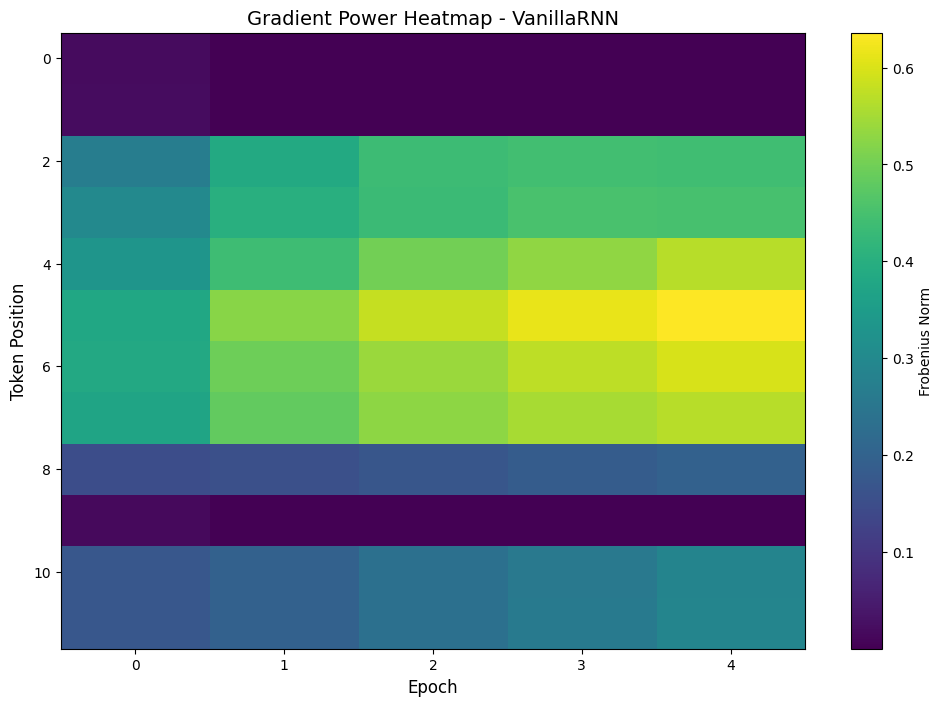

Analyzing model GRU

Epoch 1/5
  Avg Loss: 14.8409
  Mean Frobenius norm: 0.212690

Epoch 2/5
  Avg Loss: 13.1539
  Mean Frobenius norm: 0.270818

Epoch 3/5
  Avg Loss: 12.6656
  Mean Frobenius norm: 0.305768

Epoch 4/5
  Avg Loss: 12.3292
  Mean Frobenius norm: 0.333030

Epoch 5/5
  Avg Loss: 12.0328
  Mean Frobenius norm: 0.354618
Average gradient norm across all positions: 0.295385


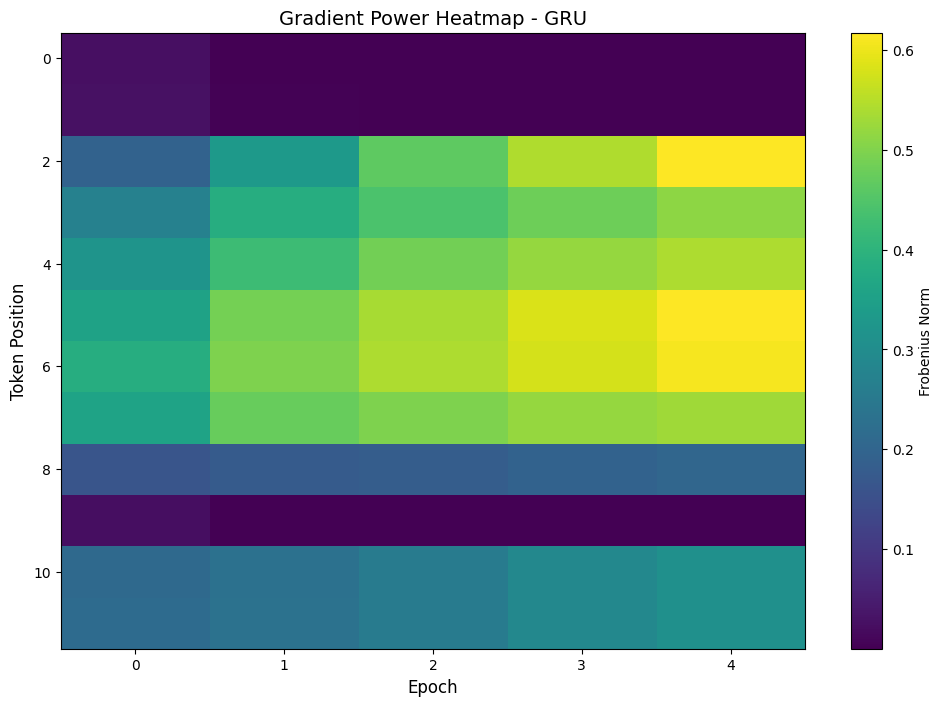

Analyzing model LSTM

Epoch 1/5
  Avg Loss: 14.9711
  Mean Frobenius norm: 0.154502

Epoch 2/5
  Avg Loss: 13.1889
  Mean Frobenius norm: 0.184949

Epoch 3/5
  Avg Loss: 12.7067
  Mean Frobenius norm: 0.203736

Epoch 4/5
  Avg Loss: 12.3949
  Mean Frobenius norm: 0.217418

Epoch 5/5
  Avg Loss: 12.0582
  Mean Frobenius norm: 0.226754
Average gradient norm across all positions: 0.197472


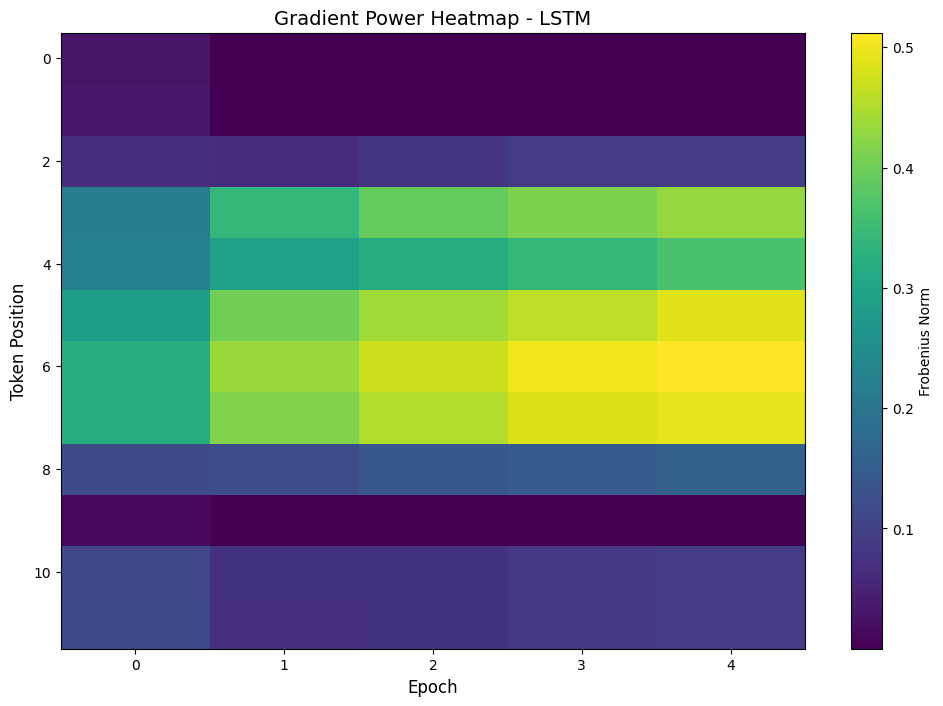

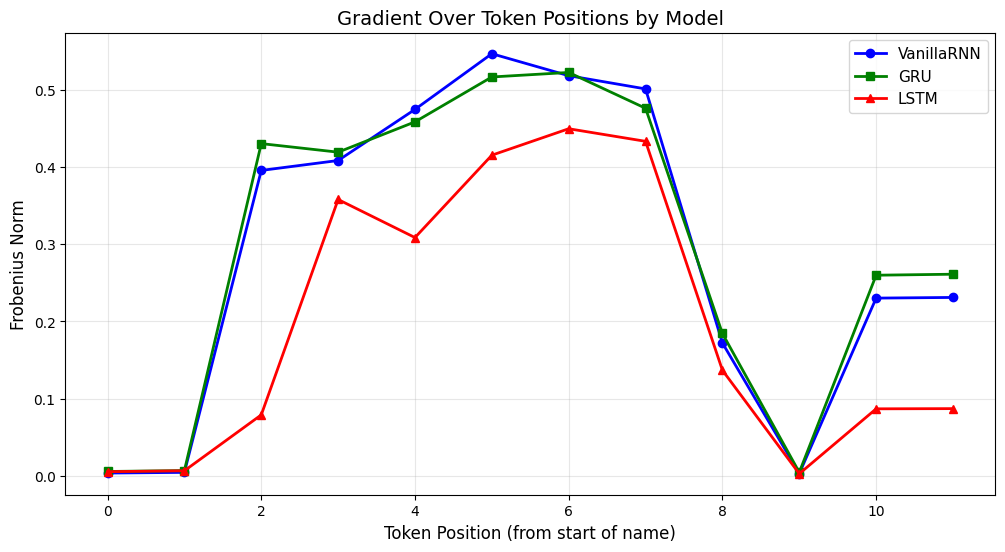

In [ ]:
models_dict = {'VanillaRNN': VanillaRNN(len(vocab), 25, 128),
               'GRU': GRUModel(len(vocab), 25, 128),
               'LSTM': LSTMModel(len(vocab), 25, 128)}

models_norms = {}

for model_name, model in models_dict.items():
    print(f"Analyzing model {model_name}")
    matrix, norms = analyze_model_gradients(model, grad_test_loader, 29, 25)
    plot_frobenius_heatmap(matrix, model_name)
    models_norms[model_name] = norms

plot_gradient_distribution(models_norms)

## 10. Multitask Learning

In [23]:
def train_func(model, train_loader, val_loader, epochs, log_interval=10):
    token_criterion = nn.CrossEntropyLoss()
    gender_criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    train_loss, val_loss = [], []

    for epoch in range(epochs):
        running_loss = 0
        num_batches = 0

        for idx, (name, gender) in enumerate(train_loader):
            optimizer.zero_grad()

            gender_target = gender.float().view(1, 1)
            token_loss = 0
            h = model.init_hidden()
            name = name[0]

            for i in range(len(name) - 1):
                inputs = name[i].view(1, 1)
                target = name[i + 1].view(1).long()

                logits, gender_logits, h = model(inputs, h)

                step_loss = token_criterion(logits.view(1, -1), target)
                token_loss += step_loss

            token_loss = token_loss / (len(name) - 1)
            gender_loss = gender_criterion(gender_logits, gender_target)
            total_loss = token_loss + gender_loss

            total_loss.backward()
            optimizer.step()

            running_loss += total_loss.item()
            num_batches += 1

            if idx % log_interval == 0:
                avg_loss = running_loss / (idx + 1)
                print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                    epoch, idx, len(train_loader.dataset),
                    100. * idx / len(train_loader), avg_loss))

        train_loss.append(running_loss / num_batches)
        val_loss.append(test_func(model, val_loader, token_criterion, gender_criterion))

    return train_loss, val_loss


In [24]:
def test_func(model, val_loader, token_criterion, gender_criterion):
    model.eval()
    val_loss = 0
    val_batches = 0
    correct_gender = 0
    total_samples = 0

    with torch.no_grad():
        for name, gender in val_loader:
            gender_target = gender.float().view(1, 1)
            token_loss = 0
            h = model.init_hidden()
            name = name[0]

            for i in range(len(name) - 1):
                inputs = name[i].view(1, 1)
                target = name[i + 1].view(1).long()

                logits, gender_logits, h = model(inputs, h)

                step_loss = token_criterion(logits.view(1, -1), target)
                token_loss += step_loss

            token_loss = token_loss / (len(name) - 1)
            gender_loss = gender_criterion(gender_logits, gender_target)

            total_loss = token_loss + gender_loss
            val_loss += total_loss.item()
            val_batches += 1

    avg_val_loss = val_loss / val_batches

    return avg_val_loss


In [25]:
set_seed()

Random seed set to: 21 (Reproducibility locked)


In [26]:
gru_model = GRUModel(len(vocab), max_len, 128)
train_loss, val_loss = train_func(gru_model, train_loader, val_loader, 15, 10000)

Train Epoch: 0 [0/5425 (0%)]	Loss: 3.968177
Train Epoch: 1 [0/5425 (0%)]	Loss: 1.569461
Train Epoch: 2 [0/5425 (0%)]	Loss: 1.268164
Train Epoch: 3 [0/5425 (0%)]	Loss: 1.058061
Train Epoch: 4 [0/5425 (0%)]	Loss: 0.982766
Train Epoch: 5 [0/5425 (0%)]	Loss: 0.960226
Train Epoch: 6 [0/5425 (0%)]	Loss: 0.960464
Train Epoch: 7 [0/5425 (0%)]	Loss: 0.908678
Train Epoch: 8 [0/5425 (0%)]	Loss: 0.872754
Train Epoch: 9 [0/5425 (0%)]	Loss: 0.836322
Train Epoch: 10 [0/5425 (0%)]	Loss: 0.854939
Train Epoch: 11 [0/5425 (0%)]	Loss: 0.894207
Train Epoch: 12 [0/5425 (0%)]	Loss: 0.876654
Train Epoch: 13 [0/5425 (0%)]	Loss: 0.890896
Train Epoch: 14 [0/5425 (0%)]	Loss: 0.852378


In [92]:
set_seed(32)

Random seed set to: 32 (Reproducibility locked)


In [93]:
start_strs = ['s', 'b', 'br', 'ak', 'm', 'la', 'pe', 'to', 'grk', 'plo']

In [94]:
for start_str in start_strs:
    temp_name = name_generator(gru_model, symbs_to_int, int_to_symbs, str_start=start_str, temperature=1, max_len=7)
    print(f'String start: {start_str} -> Result name: {temp_name}')

String start: s -> Result name: smilla
String start: b -> Result name: bie
String start: br -> Result name: bro
String start: ak -> Result name: ak
String start: m -> Result name: ma
String start: la -> Result name: lah
String start: pe -> Result name: pelvyn
String start: to -> Result name: ton
String start: grk -> Result name: grk
String start: plo -> Result name: plorece


In [55]:
test_gender_pred(gru_model, val_loader)

np.float64(0.8745824793965029)

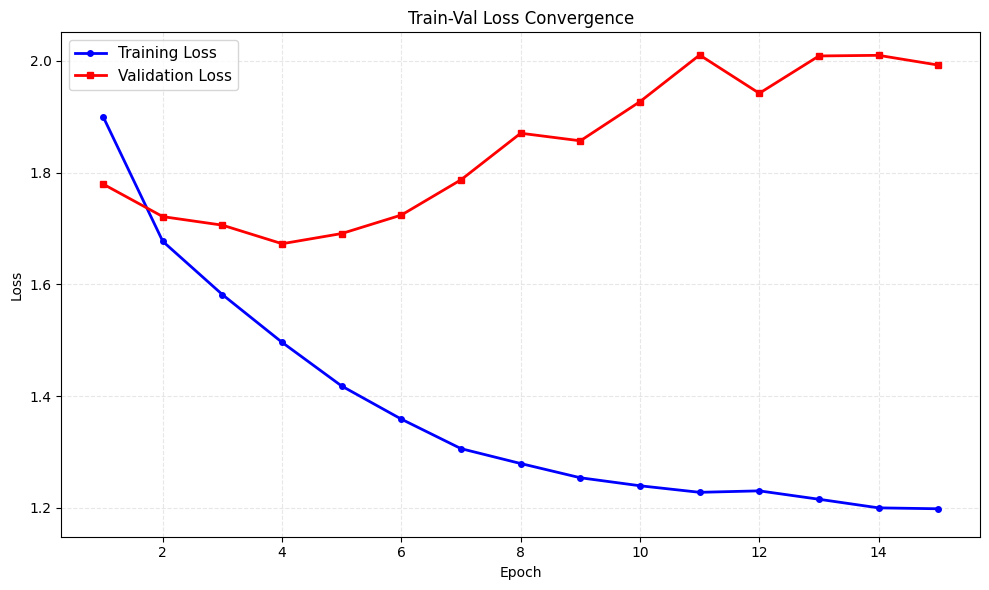

In [56]:
plot_loss_convergence(train_loss, val_loss)

In [57]:
with open('model_weights.pkl', 'wb') as f:
    pickle.dump(gru_model.state_dict(), f)

In [87]:
with open('model_weights.pkl', 'rb') as f:
    loaded_state_dict = pickle.load(f)

gru_model = GRUModel(len(vocab), max_len, 128)
gru_model.load_state_dict(loaded_state_dict)
gru_model.eval()

GRUModel(
  (embedding): Embedding(29, 13)
  (w_z_x): Linear(in_features=13, out_features=128, bias=True)
  (w_z_h): Linear(in_features=128, out_features=128, bias=True)
  (w_r_x): Linear(in_features=13, out_features=128, bias=True)
  (w_r_h): Linear(in_features=128, out_features=128, bias=True)
  (w_h_x): Linear(in_features=13, out_features=128, bias=True)
  (w_h_h): Linear(in_features=128, out_features=128, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (next_token_fc): Linear(in_features=128, out_features=29, bias=True)
  (gender_fc): Linear(in_features=128, out_features=1, bias=True)
)

## 11. Visualizing embeddings

In [95]:
set_seed(32)

Random seed set to: 32 (Reproducibility locked)


In [96]:
gru_model.eval()
embeddings = {}

for char, ind in symbs_to_int.items():
    embeddings[char] = gru_model.embedding(torch.tensor(ind).long()).detach().numpy()

In [97]:
def plot_letters(letters, coords, title="Letter Map"):
    vowels = set('aeiouy')
    plt.figure(figsize=(10, 8))

    for letter, (x, y) in zip(letters, coords):
        color = 'red' if letter in vowels else 'blue'

        plt.scatter(x, y, c=color, s=100, alpha=0.6, linewidth=1)
        plt.annotate(letter, (x, y), xytext=(5, 5), textcoords='offset points',
                    fontsize=12, fontweight='bold')

    legend_elements = [
        Patch(facecolor='red', alpha=0.6, label='Vowels'),
        Patch(facecolor='blue', alpha=0.6, label='Consonants & Other')
    ]
    plt.legend(handles=legend_elements, loc='upper right')

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [98]:
embeddings_mat = np.array([item[1] for item in embeddings.items()])
X_embedded = TSNE(n_components=2, perplexity=28, init='pca').fit_transform(embeddings_mat)

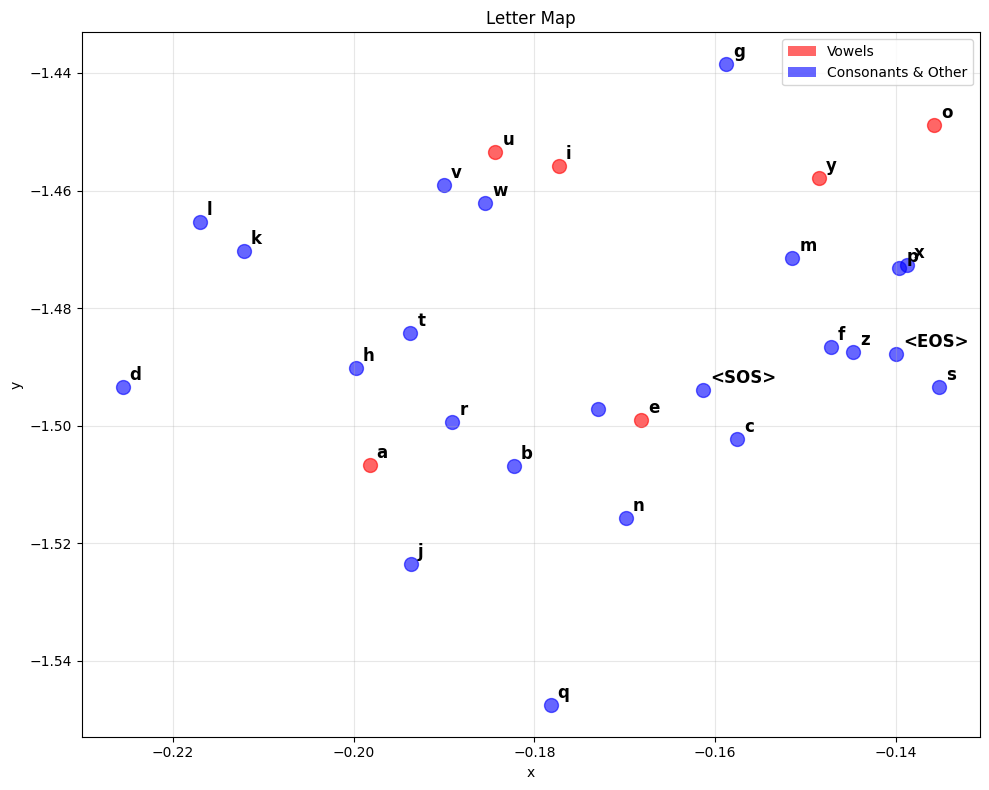

In [99]:
embed_letters = [char for char, _ in symbs_to_int.items()]
plot_letters(embed_letters, X_embedded)